In [1]:
# =============================================================================
# ÖĞRENCİ BAŞARISI TAHMİNİ — TAM PROJE KODU
# Deep Learning + XGBoost + Kapsamlı Görselleştirme
# Her "# %%" satırı Jupyter Notebook'ta yeni bir hücreyi temsil eder.
# Kurulum: pip install tensorflow xgboost scikit-learn pandas numpy matplotlib seaborn
# =============================================================================
 
# %% [markdown]
# # Öğrenci Başarısı Tahmini
# ## Deep Learning ile CGPA Regresyonu ve Akademik Risk Tespiti
# **Veri Seti:** Students Performance Dataset (1.194 öğrenci, 31 değişken)
# **Hedefler:**
# 1. CGPA Tahmini (Regresyon)
# 2. Akademik Risk Tespiti — CGPA < 2.5 (Sınıflandırma)

In [8]:
# %% HÜCRE 1 — Kütüphane İmportları
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, f1_score, roc_auc_score, roc_curve,
                              precision_score, recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.inspection import permutation_importance

import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
 
# Grafik stili
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")
 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
 
print("Tüm kütüphaneler başarıyla yüklendi.")
print(f"TensorFlow: {tf.__version__} | XGBoost: {xgb.__version__}")

Tüm kütüphaneler başarıyla yüklendi.
TensorFlow: 2.21.0 | XGBoost: 2.1.3


In [10]:
# %% HÜCRE 2 — Veri Yükleme ve İlk İnceleme
df = pd.read_csv('Students_Performance_dataset.csv')
 
# Sütun adlarını kısalt
col_map = {
    'University Admission year': 'admission_year',
    'Gender': 'gender',
    'Age': 'age',
    'H.S.C passing year': 'hsc_year',
    'Program': 'program',
    'Current Semester': 'semester',
    'Do you have meritorious scholarship ?': 'scholarship',
    'Do you use University transportation?': 'uses_transport',
    'How many hour do you study daily?': 'study_hours',
    'How many times do you seat for study in a day?': 'study_sessions',
    'What is your preferable learning mode?': 'learning_mode',
    'Do you use smart phone?': 'smartphone',
    'Do you have personal Computer?': 'has_pc',
    'How many hour do you spent daily in social media?': 'social_media_hours',
    'Status of your English language proficiency': 'english_level',
    'Average attendance on class': 'attendance',
    'Did you ever fall in probation?': 'probation',
    'Did you ever got suspension?': 'suspension',
    'Do you attend in teacher consultancy for any kind of academical problems?': 'teacher_consult',
    'What are the skills do you have ?': 'skills',
    'How many hour do you spent daily on your skill development?': 'skill_dev_hours',
    'What is you interested area?': 'interest_area',
    'What is your relationship status?': 'relationship',
    'Are you engaged with any co-curriculum activities?': 'co_curriculum',
    'With whom you are living with?': 'living_with',
    'Do you have any health issues?': 'health_issues',
    'What was your previous SGPA?': 'prev_sgpa',
    'Do you have any physical disabilities?': 'physical_disability',
    'What is your current CGPA?': 'cgpa',
    'How many Credit did you have completed?': 'credits_completed',
    'What is your monthly family income?': 'family_income'
}
df = df.rename(columns=col_map)
 
print(f"Veri boyutu: {df.shape}")
print(f"\nİlk 5 satır:")
df.head()

Veri boyutu: (1194, 31)

İlk 5 satır:


,admission_year,gender,age,hsc_year,program,semester,scholarship,uses_transport,study_hours,study_sessions,...,interest_area,relationship,co_curriculum,living_with,health_issues,prev_sgpa,physical_disability,cgpa,credits_completed,family_income
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000
2,2020,Female,21,2019,BCSE,5,No,No,3,3,...,Software,Single,No,Bachelor,No,2.68,No,3.15,50,50000
3,2021,Male,20,2020,BCSE,4,Yes,No,1,3,...,Artificial Intelligence,Single,No,Bachelor,Yes,2.68,No,3.15,36,62488
4,2021,Male,22,2019,BCSE,4,Yes,No,3,1,...,Software,Relationship,No,Bachelor,Yes,2.68,No,3.15,36,50000


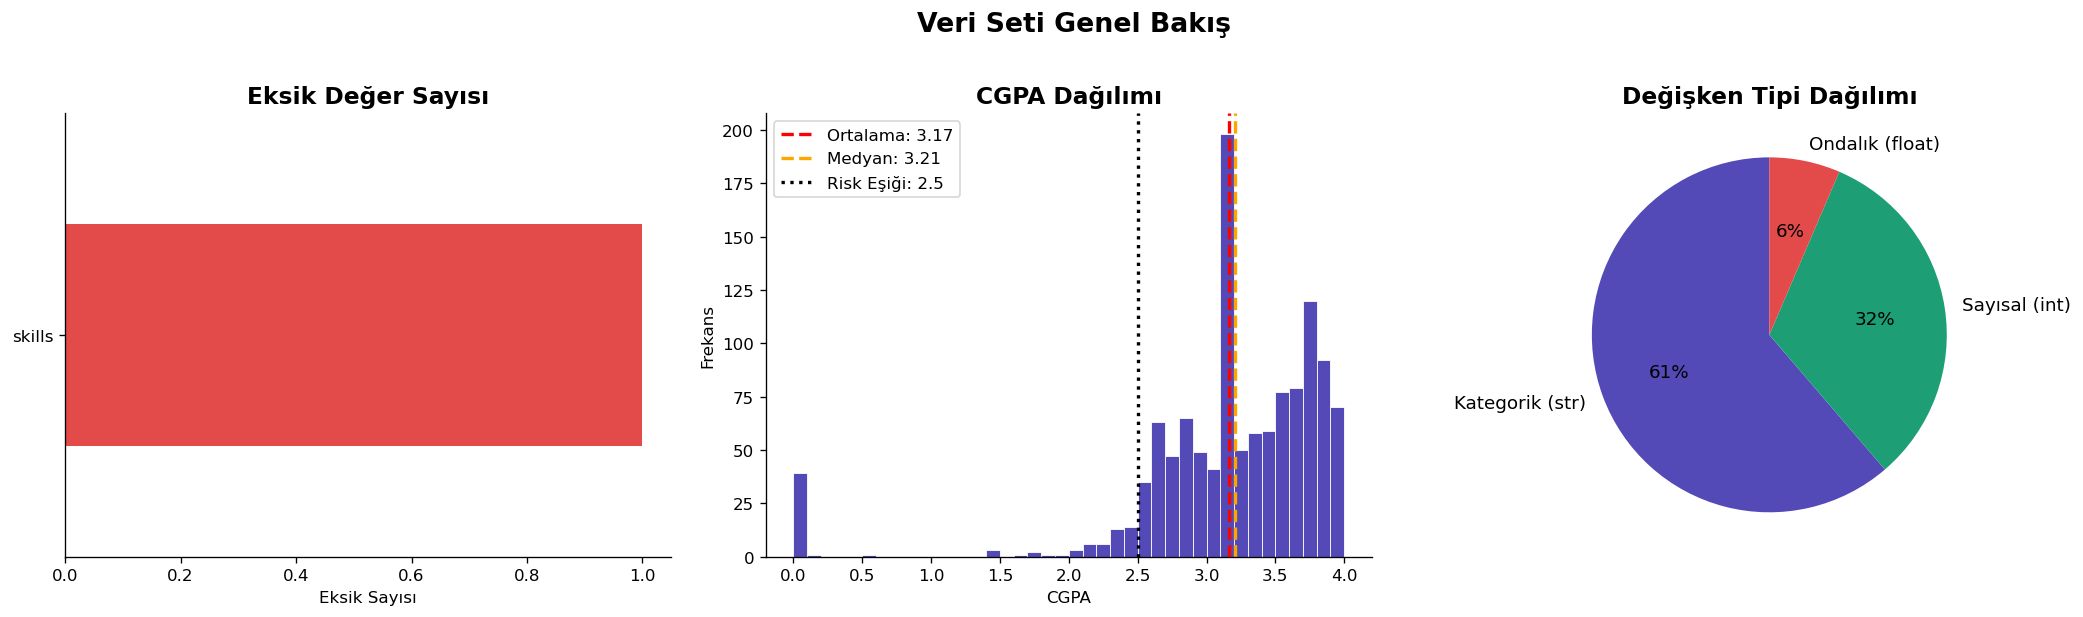

       admission_year       age  hsc_year  semester  study_hours  \
count        1194.000  1194.000  1194.000  1194.000     1194.000   
mean         2020.515    21.343  2019.214     6.539        3.131   
std             1.355     1.613     1.381     3.810        1.650   
min          2013.000    18.000  2012.000     1.000        0.000   
25%          2020.000    20.000  2019.000     3.000        2.000   
50%          2021.000    21.000  2020.000     7.000        3.000   
75%          2022.000    22.000  2020.000    10.000        4.000   
max          2023.000    27.000  2028.000    24.000       13.000   

       study_sessions  social_media_hours  skill_dev_hours  prev_sgpa  \
count        1194.000             1194.00         1194.000   1194.000   
mean            1.941                3.29            2.185      2.684   
std             0.856                2.29            1.296      0.872   
min             0.000                0.00            0.000      0.000   
25%             1.000 

In [11]:
# %% HÜCRE 3 — EDA: Genel İstatistikler ve Eksik Değer Analizi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# 1. Eksik değer grafiği
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    missing.plot(kind='barh', ax=axes[0], color='#E24B4A')
    axes[0].set_title('Eksik Değer Sayısı', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Eksik Sayısı')
else:
    axes[0].text(0.5, 0.5, 'Eksik Değer Yok!\n(1 adet skills)', ha='center', va='center',
                 fontsize=14, color='green', transform=axes[0].transAxes)
    axes[0].set_title('Eksik Değer Analizi', fontsize=14, fontweight='bold')
 
# 2. CGPA dağılımı
axes[1].hist(df['cgpa'], bins=40, color='#534AB7', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['cgpa'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Ortalama: {df["cgpa"].mean():.2f}')
axes[1].axvline(df['cgpa'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Medyan: {df["cgpa"].median():.2f}')
axes[1].axvline(2.5, color='black', linestyle=':', linewidth=2,
                label='Risk Eşiği: 2.5')
axes[1].set_title('CGPA Dağılımı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('CGPA')
axes[1].set_ylabel('Frekans')
axes[1].legend(fontsize=10)
 
# 3. Veri tipi dağılımı
dtype_counts = df.dtypes.map(str).value_counts()
colors_pie = ['#534AB7', '#1D9E75', '#E24B4A']
axes[2].pie(dtype_counts.values, labels=['Kategorik (str)', 'Sayısal (int)', 'Ondalık (float)'],
            colors=colors_pie[:len(dtype_counts)], autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 11})
axes[2].set_title('Değişken Tipi Dağılımı', fontsize=14, fontweight='bold')
 
plt.suptitle('Veri Seti Genel Bakış', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_genel_bakis.png', bbox_inches='tight', dpi=150)
plt.show()
print(df.describe().round(3))

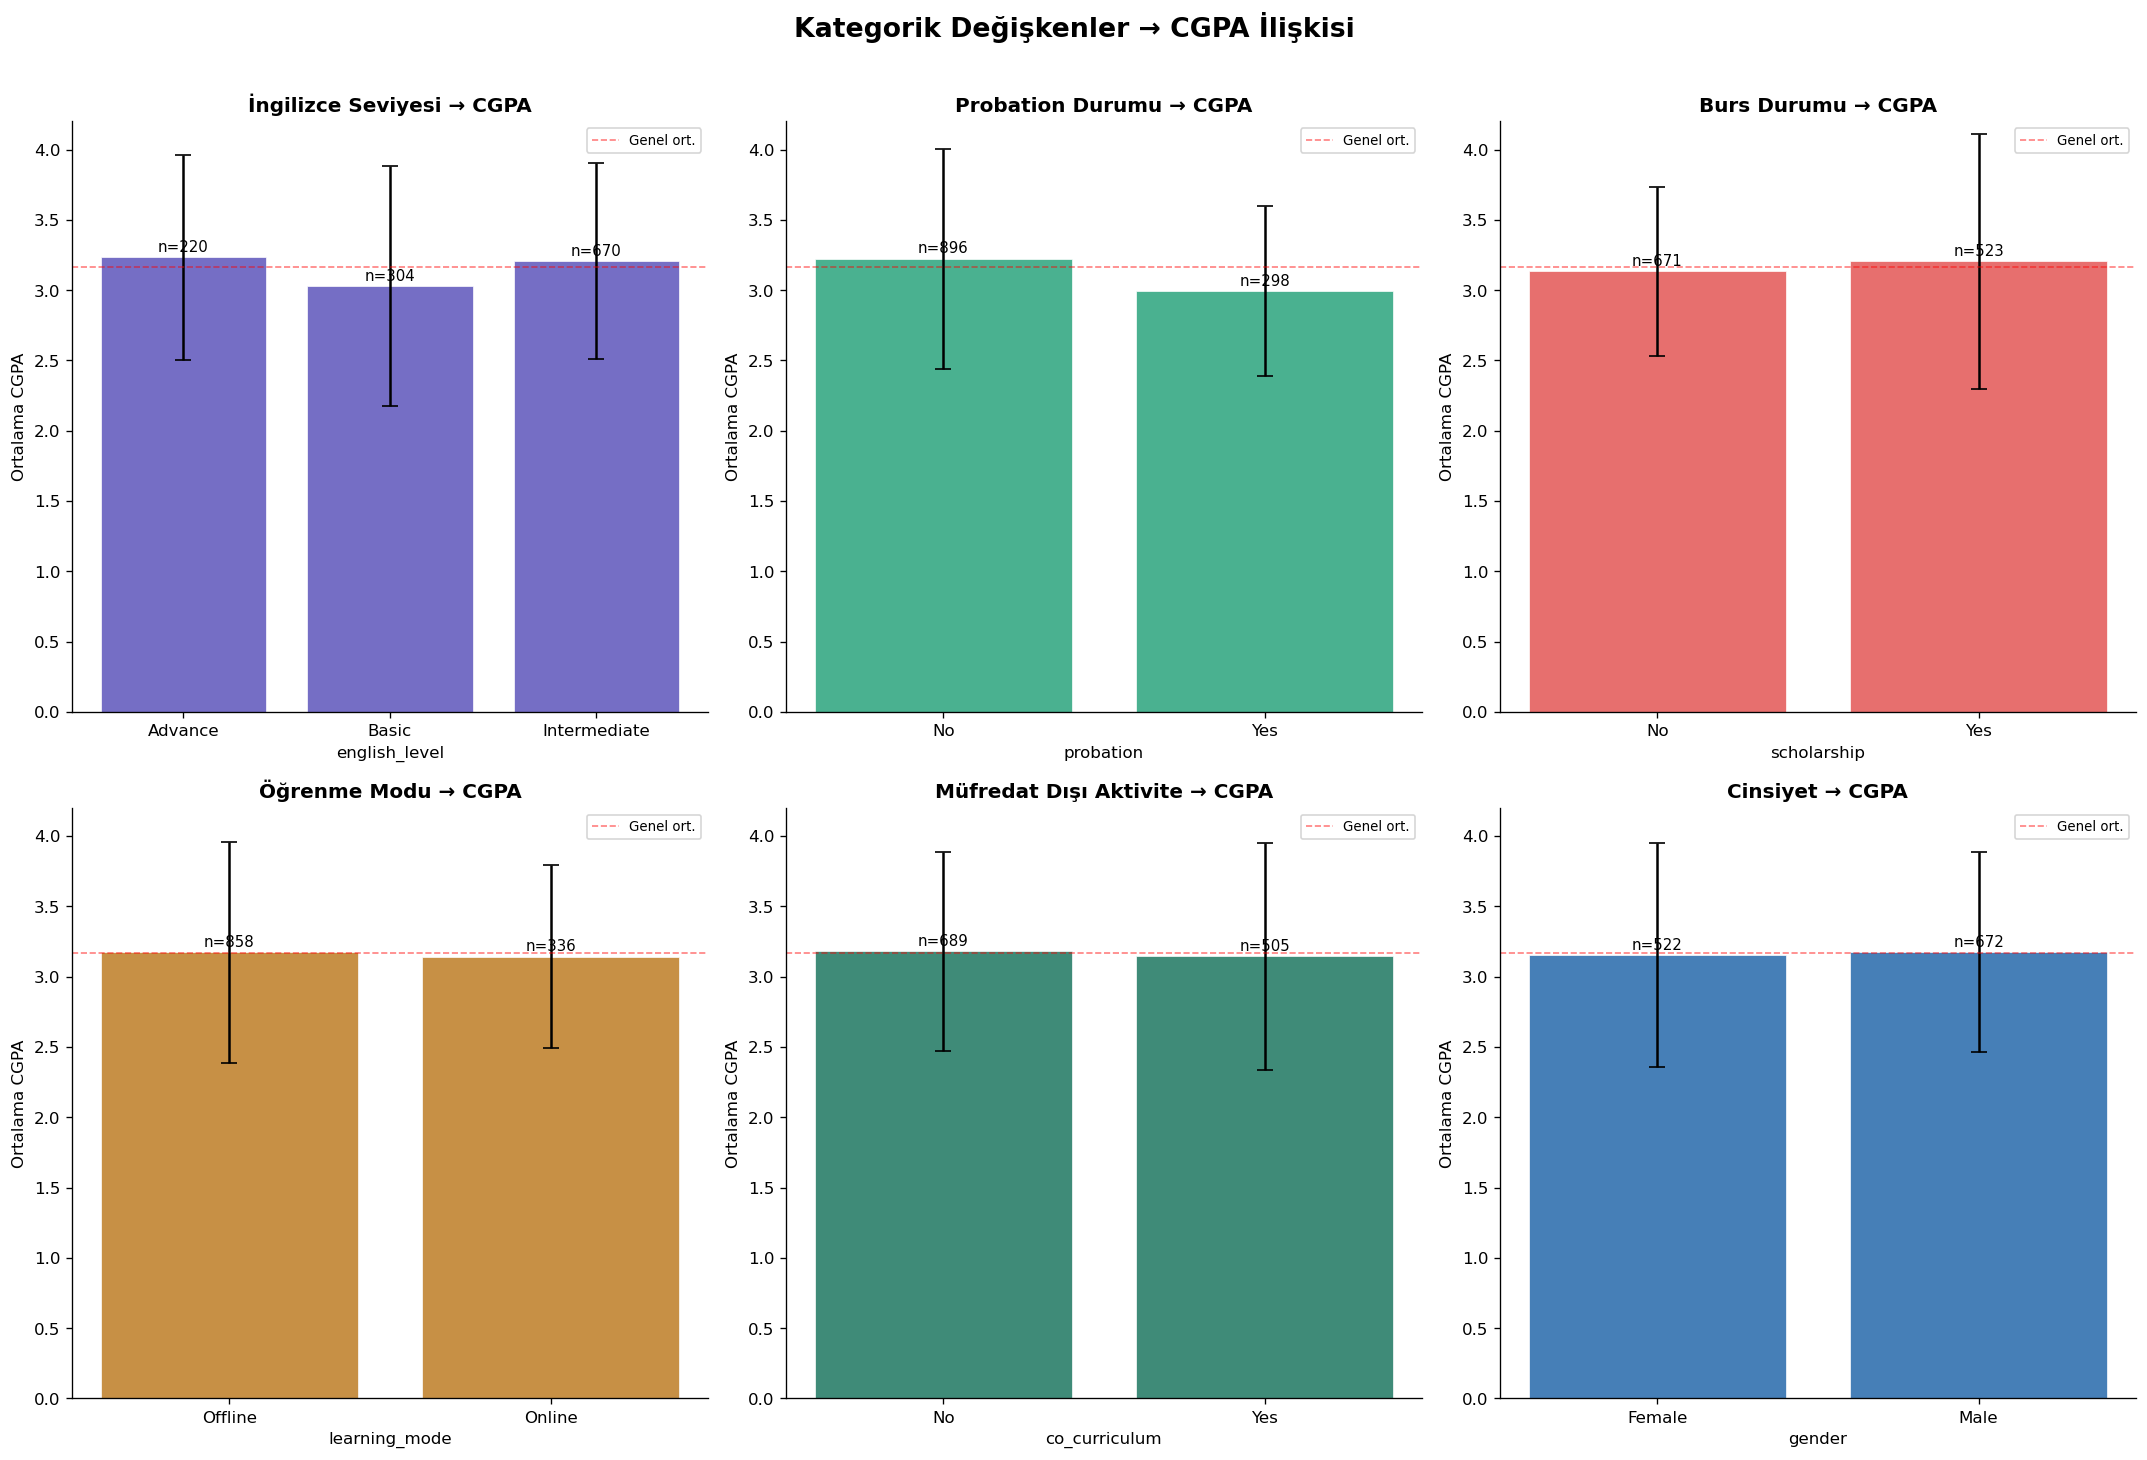

In [12]:
# %% HÜCRE 4 — EDA: CGPA Kategorisel Analiz
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
 
cat_features = ['english_level', 'probation', 'scholarship',
                'learning_mode', 'co_curriculum', 'gender']
titles = ['İngilizce Seviyesi', 'Probation Durumu', 'Burs Durumu',
          'Öğrenme Modu', 'Müfredat Dışı Aktivite', 'Cinsiyet']
colors_bar = ['#534AB7', '#1D9E75', '#E24B4A', '#BA7517', '#0F6E56', '#185FA5']
 
for idx, (col, title, color) in enumerate(zip(cat_features, titles, colors_bar)):
    ax = axes[idx // 3][idx % 3]
    grp = df.groupby(col)['cgpa'].agg(['mean', 'std', 'count']).reset_index()
    bars = ax.bar(grp[col].astype(str), grp['mean'],
                  color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.errorbar(range(len(grp)), grp['mean'], yerr=grp['std'],
                fmt='none', color='black', capsize=5, linewidth=1.5)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'n={int(row["count"])}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{title} → CGPA', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Ortalama CGPA')
    ax.set_ylim(0, 4.2)
    ax.axhline(df['cgpa'].mean(), color='red', linestyle='--',
               alpha=0.5, linewidth=1, label='Genel ort.')
    ax.legend(fontsize=8)
 
plt.suptitle('Kategorik Değişkenler → CGPA İlişkisi', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_kategorik_analiz.png', bbox_inches='tight', dpi=150)
plt.show()

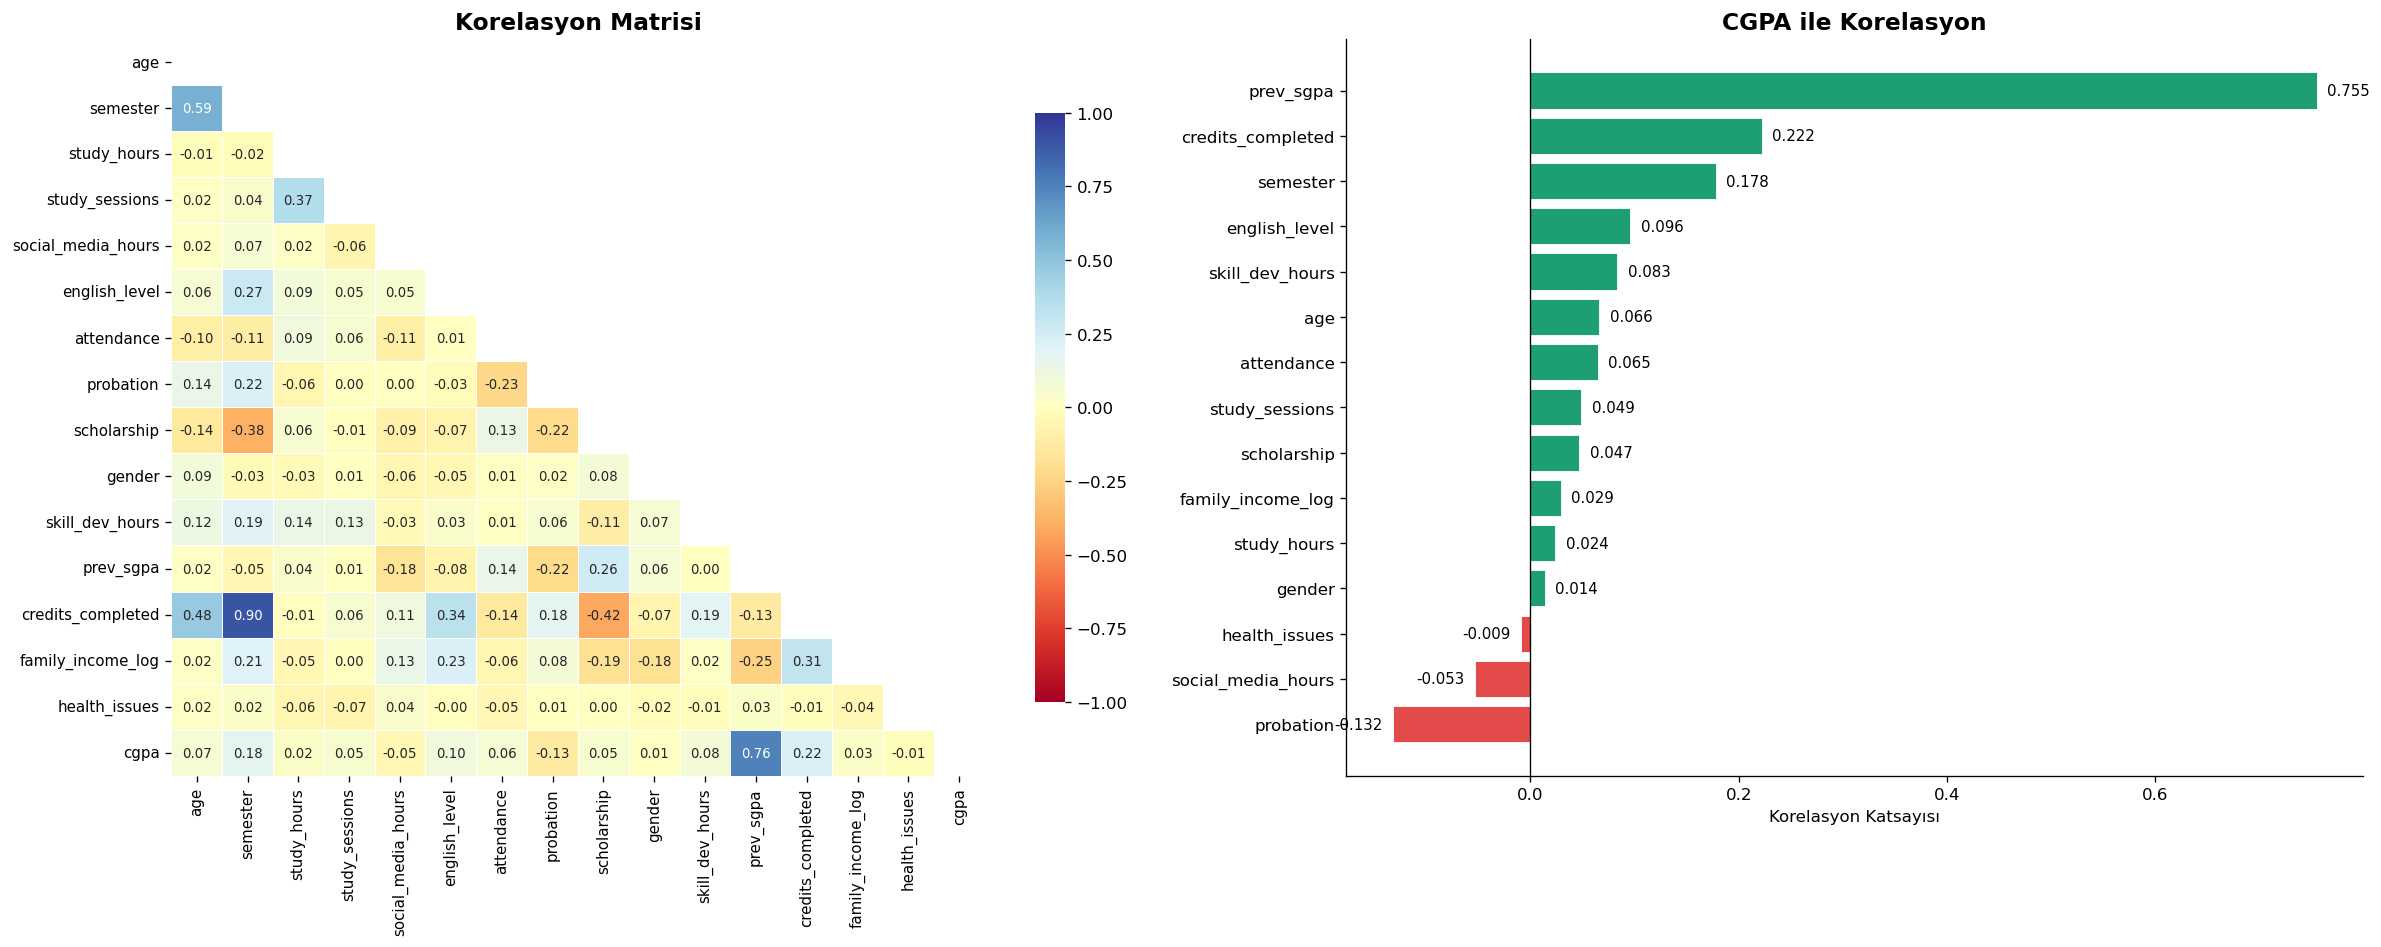

In [13]:
# %% HÜCRE 5 — EDA: Korelasyon Isı Haritası
# Temizlik için geçici encode
df_corr = df.copy()
df_corr['english_level'] = df_corr['english_level'].map({'Basic':0,'Intermediate':1,'Advance':2})
df_corr['health_issues'] = df_corr['health_issues'].str.strip().str.lower()
df_corr['health_issues'] = df_corr['health_issues'].map({'yes':1,'no':0,'n':0}).fillna(0)
df_corr['probation']     = (df_corr['probation'] == 'Yes').astype(int)
df_corr['scholarship']   = (df_corr['scholarship'] == 'Yes').astype(int)
df_corr['gender']        = (df_corr['gender'] == 'Male').astype(int)
df_corr['attendance']    = pd.to_numeric(df_corr['attendance'], errors='coerce').fillna(
    pd.to_numeric(df_corr['attendance'], errors='coerce').median())
df_corr['family_income_log'] = np.log1p(df_corr['family_income'])
 
num_cols_corr = ['age','semester','study_hours','study_sessions','social_media_hours',
                 'english_level','attendance','probation','scholarship','gender',
                 'skill_dev_hours','prev_sgpa','credits_completed','family_income_log',
                 'health_issues','cgpa']
 
corr_matrix = df_corr[num_cols_corr].corr()
 
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
 
# Tam korelasyon matrisi
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Korelasyon Matrisi', fontsize=14, fontweight='bold')
axes[0].tick_params(labelsize=9)
 
# CGPA ile korelasyon (bar chart)
cgpa_corr = corr_matrix['cgpa'].drop('cgpa').sort_values()
colors_corr = ['#E24B4A' if x < 0 else '#1D9E75' for x in cgpa_corr]
bars = axes[1].barh(range(len(cgpa_corr)), cgpa_corr.values,
                    color=colors_corr, edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(len(cgpa_corr)))
axes[1].set_yticklabels(cgpa_corr.index, fontsize=10)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Korelasyon Katsayısı')
axes[1].set_title('CGPA ile Korelasyon', fontsize=14, fontweight='bold')
for bar, val in zip(bars, cgpa_corr.values):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)
 
plt.tight_layout()
plt.savefig('03_korelasyon.png', bbox_inches='tight', dpi=150)
plt.show()

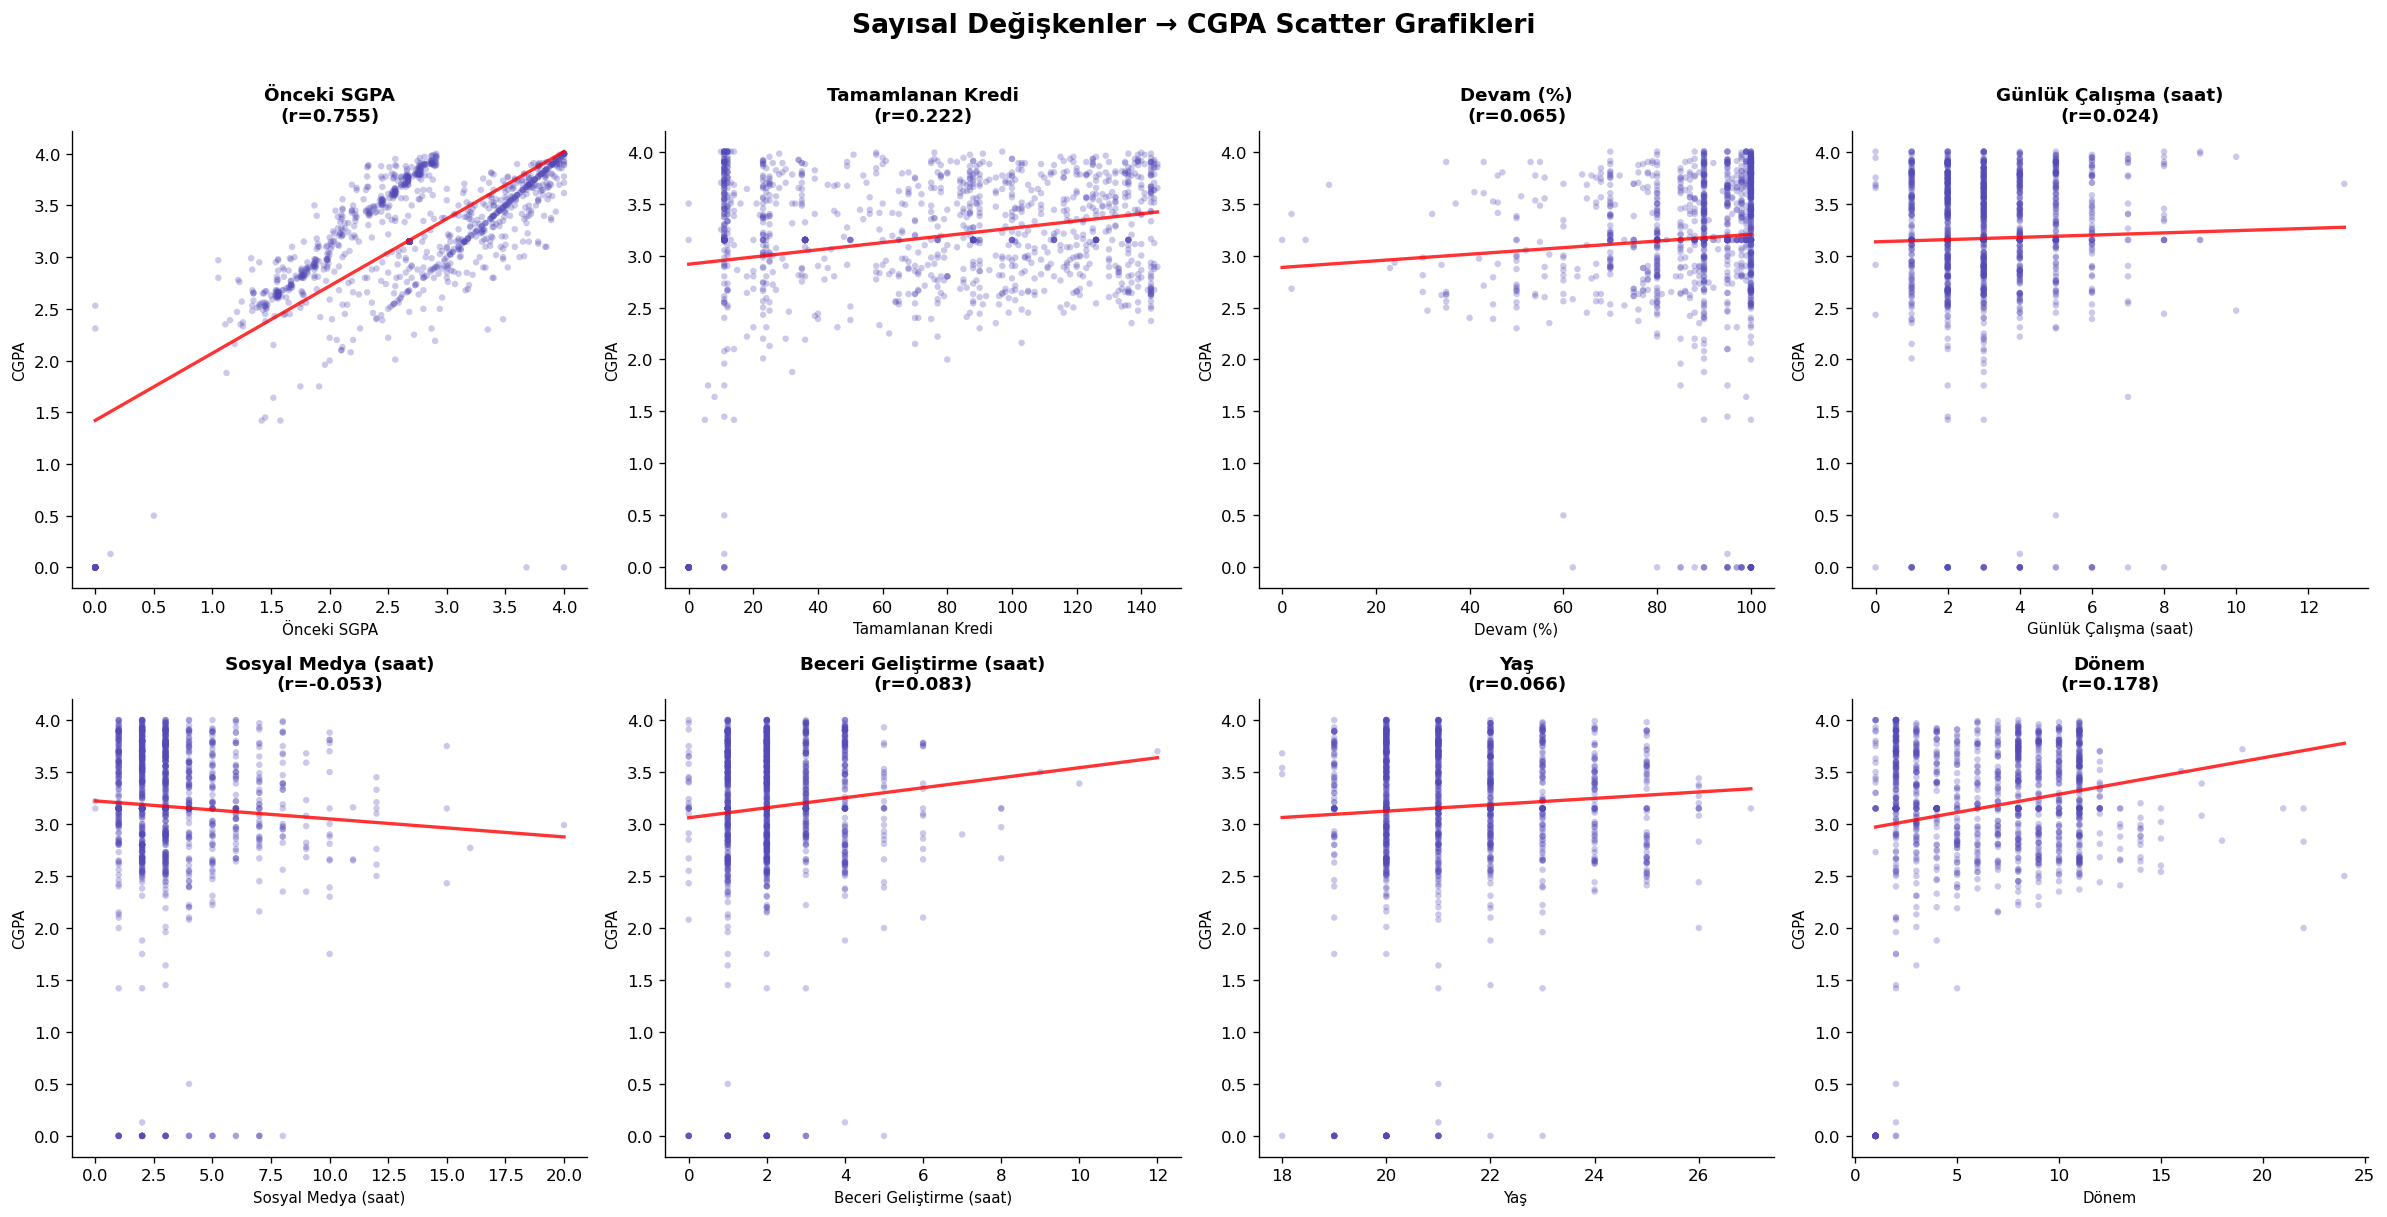

In [14]:
# %% HÜCRE 6 — EDA: Sayısal Değişken Dağılımları (Scatter & Box)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
 
scatter_feats = ['prev_sgpa', 'credits_completed', 'attendance',
                 'study_hours', 'social_media_hours', 'skill_dev_hours',
                 'age', 'semester']
feat_labels = ['Önceki SGPA', 'Tamamlanan Kredi', 'Devam (%)',
               'Günlük Çalışma (saat)', 'Sosyal Medya (saat)', 'Beceri Geliştirme (saat)',
               'Yaş', 'Dönem']
 
for idx, (feat, label) in enumerate(zip(scatter_feats, feat_labels)):
    ax = axes[idx // 4][idx % 4]
    if feat in df_corr.columns:
        ax.scatter(df_corr[feat], df_corr['cgpa'],
                   alpha=0.3, color='#534AB7', s=15, edgecolor='none')
        z = np.polyfit(df_corr[feat].dropna(), df_corr.loc[df_corr[feat].notna(), 'cgpa'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_corr[feat].min(), df_corr[feat].max(), 100)
        ax.plot(x_line, p(x_line), 'r-', linewidth=2, alpha=0.8)
        corr_val = df_corr[feat].corr(df_corr['cgpa'])
        ax.set_title(f'{label}\n(r={corr_val:.3f})', fontsize=11, fontweight='bold')
        ax.set_xlabel(label, fontsize=9)
        ax.set_ylabel('CGPA', fontsize=9)
 
plt.suptitle('Sayısal Değişkenler → CGPA Scatter Grafikleri', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_scatter_plots.png', bbox_inches='tight', dpi=150)
plt.show()
 

  PREPROCESSING & FEATURE ENGINEERING
Temizlik sonrası: (1155, 31)
Yeni feature'lar: study_efficiency, digital_balance, age_semester_ratio, skill_count, family_income_log
Outlier winsorization (1%-99%): tamamlandı
Encoding: ordinal + binary tamamlandı

Final feature sayısı : 28
Örnekler             : 1155
Risk grubu (CGPA<2.5): 52 (4.5%)


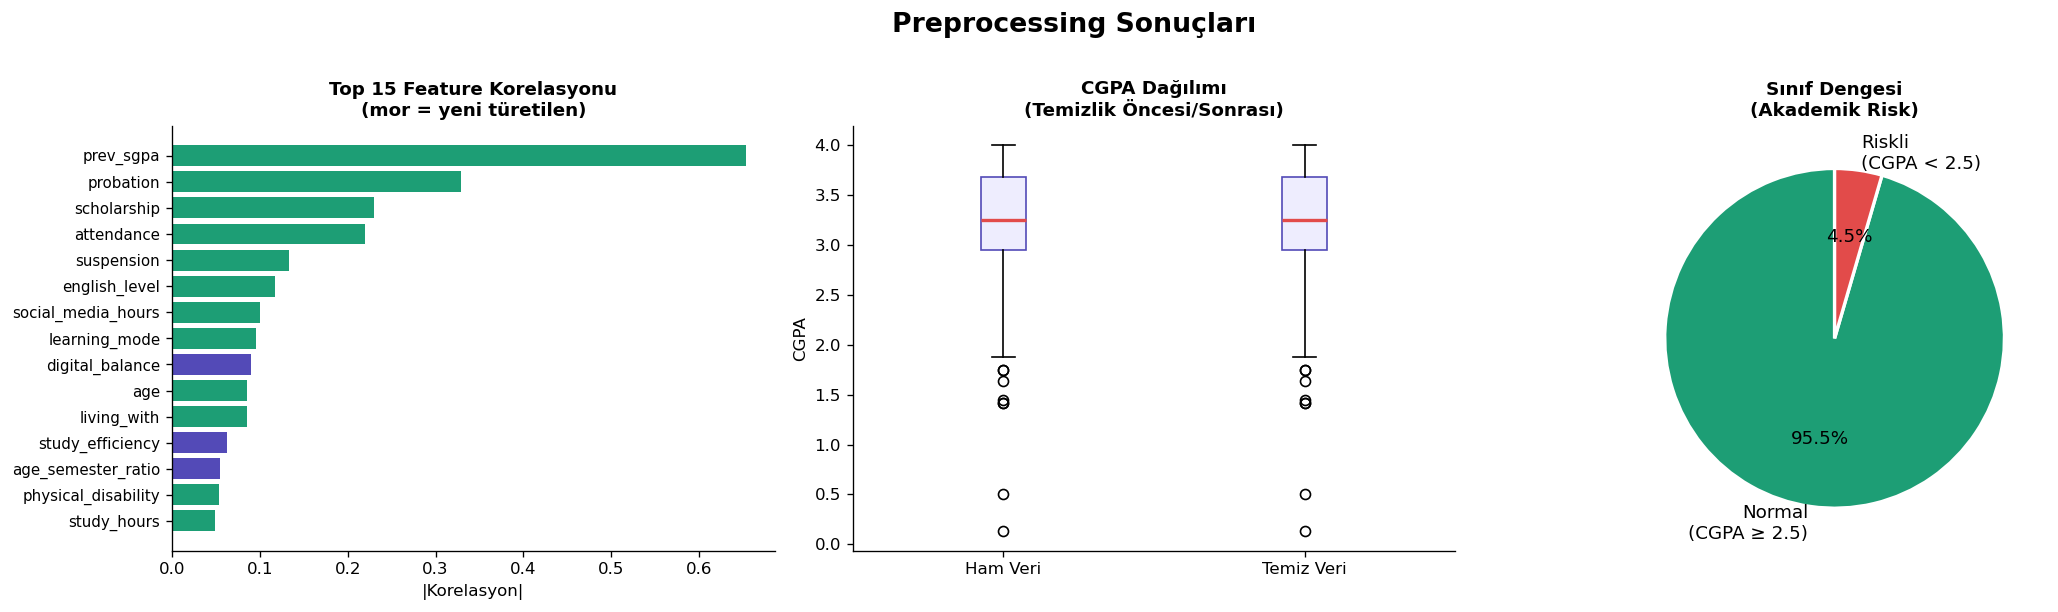

In [15]:
# %% HÜCRE 7 — Preprocessing & Feature Engineering
print("=" * 55)
print("  PREPROCESSING & FEATURE ENGINEERING")
print("=" * 55)
 
# Kopya al
df_ml = df.copy()
 
# 1. Temizlik
df_ml['health_issues'] = df_ml['health_issues'].str.strip().str.lower()
df_ml['health_issues'] = df_ml['health_issues'].map({'yes':'Yes','no':'No','n':'No'}).fillna('No')
df_ml['attendance'] = pd.to_numeric(df_ml['attendance'], errors='coerce')
df_ml['attendance'] = df_ml['attendance'].fillna(df_ml['attendance'].median())
df_ml['skills'] = df_ml['skills'].fillna('Unknown')
df_ml = df_ml[df_ml['cgpa'] > 0].reset_index(drop=True)
print(f"Temizlik sonrası: {df_ml.shape}")
 
# 2. Feature Engineering
df_ml['family_income_log']  = np.log1p(df_ml['family_income'])
df_ml['skill_count']        = df_ml['skills'].str.split(',').str.len()
df_ml['study_efficiency']   = df_ml['study_hours'] * df_ml['study_sessions']
df_ml['digital_balance']    = df_ml['skill_dev_hours'] - df_ml['social_media_hours']
df_ml['age_semester_ratio'] = df_ml['age'] / (df_ml['semester'] + 1)
print("Yeni feature'lar: study_efficiency, digital_balance, age_semester_ratio, skill_count, family_income_log")
 
# 3. Outlier winsorization (IQR)
winsor_cols = ['prev_sgpa','credits_completed','family_income_log',
               'attendance','social_media_hours','study_hours']
for col in winsor_cols:
    q1, q3 = df_ml[col].quantile(0.01), df_ml[col].quantile(0.99)
    df_ml[col] = df_ml[col].clip(q1, q3)
print("Outlier winsorization (1%-99%): tamamlandı")
 
# 4. Encoding
df_ml['english_level'] = df_ml['english_level'].map({'Basic':0,'Intermediate':1,'Advance':2})
binary_cols = ['gender','scholarship','uses_transport','learning_mode',
               'smartphone','has_pc','probation','suspension',
               'teacher_consult','co_curriculum','health_issues','physical_disability']
for col in binary_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
df_ml['living_with'] = (df_ml['living_with'] == 'Family').astype(int)
print("Encoding: ordinal + binary tamamlandı")
 
# 5. Drop
drop_cols = ['program','skills','interest_area','relationship',
             'admission_year','hsc_year','family_income']
df_ml.drop(columns=drop_cols, inplace=True)
 
# 6. Hedef değişkenler
df_ml['cgpa_risk'] = (df_ml['cgpa'] < 2.5).astype(int)
feature_cols = [c for c in df_ml.columns if c not in ['cgpa','cgpa_risk']]
 
X = df_ml[feature_cols].values
y_reg = df_ml['cgpa'].values
y_clf = df_ml['cgpa_risk'].values
 
print(f"\nFinal feature sayısı : {len(feature_cols)}")
print(f"Örnekler             : {X.shape[0]}")
print(f"Risk grubu (CGPA<2.5): {y_clf.sum()} ({y_clf.mean():.1%})")
 
# Preprocessing görselleştirmesi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Feature korelasyonları (yeni türetilenler dahil)
df_feat_corr = pd.DataFrame(X, columns=feature_cols)
df_feat_corr['cgpa'] = y_reg
top_corr = df_feat_corr.corr()['cgpa'].drop('cgpa').abs().sort_values(ascending=True).tail(15)
colors_imp = ['#534AB7' if f in ['study_efficiency','digital_balance','age_semester_ratio',
              'skill_count','family_income_log'] else '#1D9E75' for f in top_corr.index]
axes[0].barh(range(len(top_corr)), top_corr.values, color=colors_imp)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index, fontsize=9)
axes[0].set_title('Top 15 Feature Korelasyonu\n(mor = yeni türetilen)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('|Korelasyon|')
 
# CGPA dağılımı — öncesi/sonrası temizlik
axes[1].boxplot([df[df['cgpa'] > 0]['cgpa'].values, df_ml['cgpa'].values],
                labels=['Ham Veri', 'Temiz Veri'],
                patch_artist=True,
                boxprops=dict(facecolor='#EEEDFE', color='#534AB7'),
                medianprops=dict(color='#E24B4A', linewidth=2))
axes[1].set_title('CGPA Dağılımı\n(Temizlik Öncesi/Sonrası)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('CGPA')
 
# Sınıf dengesi
labels_risk = ['Normal\n(CGPA ≥ 2.5)', 'Riskli\n(CGPA < 2.5)']
sizes = [len(y_clf) - y_clf.sum(), y_clf.sum()]
colors_pie2 = ['#1D9E75', '#E24B4A']
wedges, texts, autotexts = axes[2].pie(sizes, labels=labels_risk, colors=colors_pie2,
                                        autopct='%1.1f%%', startangle=90,
                                        textprops={'fontsize': 11},
                                        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Sınıf Dengesi\n(Akademik Risk)', fontsize=11, fontweight='bold')
 
plt.suptitle('Preprocessing Sonuçları', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('05_preprocessing.png', bbox_inches='tight', dpi=150)
plt.show()
 

Train: 924 | Test: 231
SMOTE sonrası train: 1344 (Risk: 462)


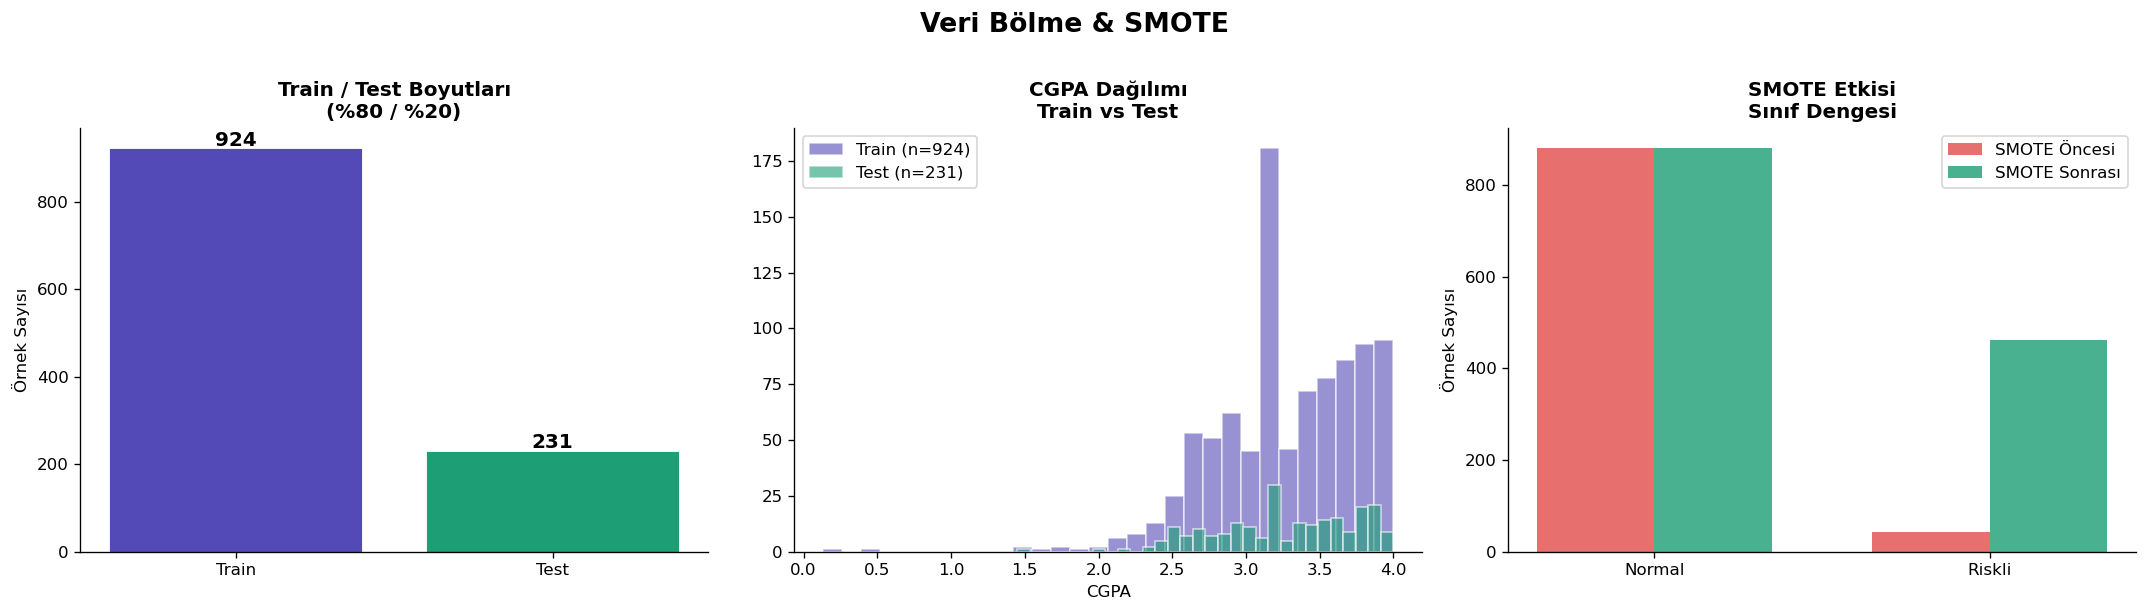

In [16]:
# %% HÜCRE 8 — Train/Test Split & SMOTE
# Train/Test Split (stratified)
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
 
# RobustScaler
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
 
# Manuel SMOTE
def manual_smote(X, y, k=5, multiplier=10, random_state=42):
    rng = np.random.RandomState(random_state)
    minority_idx = np.where(y == 1)[0]
    X_min = X[minority_idx]
    synthetic = []
    for _ in range(len(minority_idx) * multiplier):
        idx = rng.randint(0, len(X_min))
        sample = X_min[idx]
        dists = np.linalg.norm(X_min - sample, axis=1)
        dists[idx] = np.inf
        nn_idx = np.argsort(dists)[:k]
        nn = X_min[rng.choice(nn_idx)]
        synthetic.append(sample + rng.random() * (nn - sample))
    X_syn = np.array(synthetic)
    return np.vstack([X, X_syn]), np.concatenate([y, np.ones(len(X_syn), dtype=int)])
 
X_train_sm, yc_train_sm = manual_smote(X_train_sc, yc_train)
 
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"SMOTE sonrası train: {X_train_sm.shape[0]} (Risk: {yc_train_sm.sum()})")
 
# Split görselleştirmesi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Train/test boyutları
axes[0].bar(['Train', 'Test'], [X_train.shape[0], X_test.shape[0]],
            color=['#534AB7', '#1D9E75'], edgecolor='white', linewidth=0.5)
for i, v in enumerate([X_train.shape[0], X_test.shape[0]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Train / Test Boyutları\n(%80 / %20)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Örnek Sayısı')
 
# CGPA dağılımı train/test
axes[1].hist(yr_train, bins=30, alpha=0.6, color='#534AB7',
             label=f'Train (n={len(yr_train)})', edgecolor='white')
axes[1].hist(yr_test, bins=30, alpha=0.6, color='#1D9E75',
             label=f'Test (n={len(yr_test)})', edgecolor='white')
axes[1].set_title('CGPA Dağılımı\nTrain vs Test', fontsize=12, fontweight='bold')
axes[1].set_xlabel('CGPA')
axes[1].legend()
 
# SMOTE öncesi/sonrası
labels_sm = ['Normal', 'Riskli']
before = [(yc_train == 0).sum(), (yc_train == 1).sum()]
after  = [(yc_train_sm == 0).sum(), (yc_train_sm == 1).sum()]
x_sm = np.arange(2)
w = 0.35
axes[2].bar(x_sm - w/2, before, w, label='SMOTE Öncesi', color='#E24B4A', alpha=0.8)
axes[2].bar(x_sm + w/2, after, w, label='SMOTE Sonrası', color='#1D9E75', alpha=0.8)
axes[2].set_xticks(x_sm)
axes[2].set_xticklabels(labels_sm)
axes[2].set_title('SMOTE Etkisi\nSınıf Dengesi', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Örnek Sayısı')
axes[2].legend()
 
plt.suptitle('Veri Bölme & SMOTE', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('06_split_smote.png', bbox_inches='tight', dpi=150)
plt.show()
 

  KERAS DEEP LEARNING — REGRESYON


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           3,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 448 (1.75 KB)


Epoch 108: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 116: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Eğitim tamamlandı. Epoch: 120
Keras DL  → MAE=0.2626  RMSE=0.3373  R²=0.5032


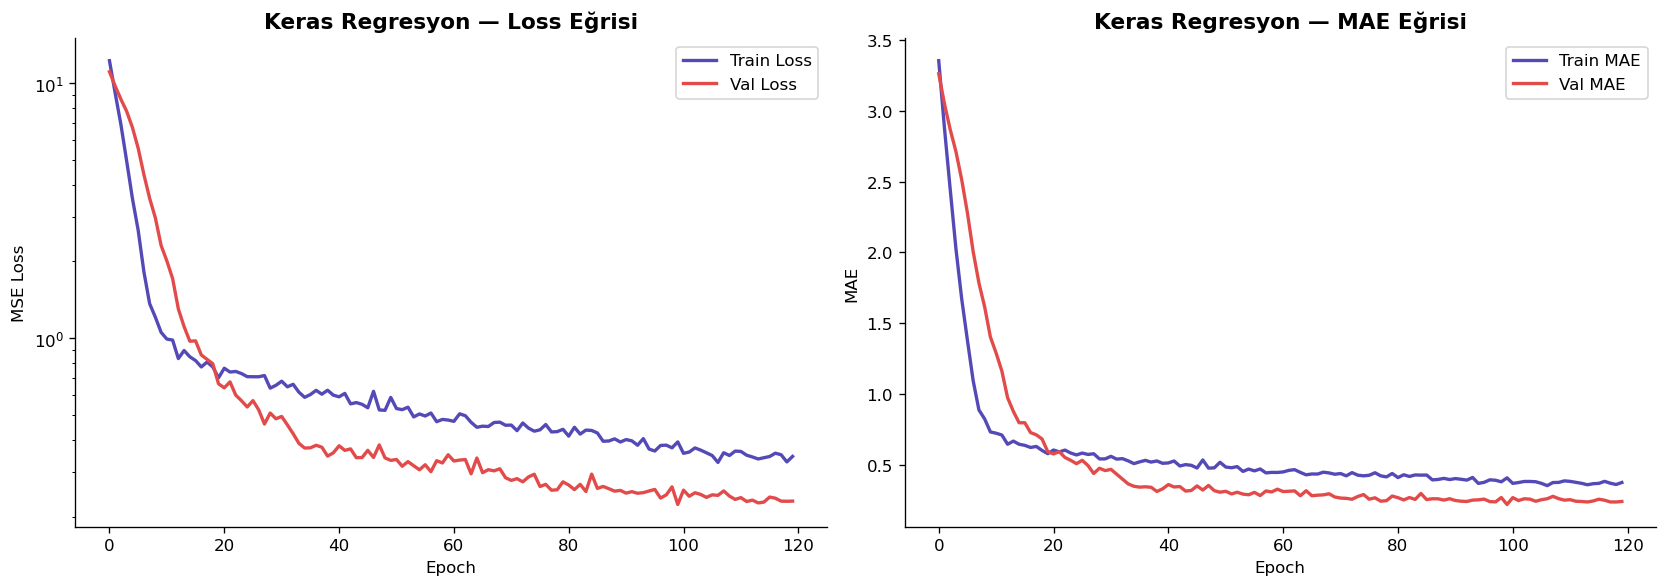

In [17]:
# %% HÜCRE 9 — Keras Deep Learning — Regresyon Modeli
print("=" * 55)
print("  KERAS DEEP LEARNING — REGRESYON")
print("=" * 55)
 
def build_keras_reg(input_dim, units=(128, 64, 32), dropout_rate=0.3,
                    l2_reg=1e-3, learning_rate=1e-3, activation='relu'):
    inputs = keras.Input(shape=(input_dim,))
 
    # Blok 1
    x = layers.Dense(units[0], kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.Dropout(dropout_rate)(x)
 
    # Blok 2
    x = layers.Dense(units[1], kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.Dropout(dropout_rate)(x)
 
    # Blok 3
    x = layers.Dense(units[2], kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.Dropout(dropout_rate / 2)(x)
 
    # Output
    output = layers.Dense(1, activation='linear')(x)
 
    model = keras.Model(inputs, output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model
 
# Callbacks
cb_reg = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=8, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_reg_model.h5', monitor='val_loss',
                    save_best_only=True, verbose=0)
]
 
# Model özeti
keras_reg = build_keras_reg(X_train_sc.shape[1], dropout_rate=0.3,
                             l2_reg=1e-3, learning_rate=1e-3)
keras_reg.summary()
 
# Eğitim
history_reg = keras_reg.fit(
    X_train_sc, yr_train,
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    callbacks=cb_reg,
    verbose=0
)
print(f"Eğitim tamamlandı. Epoch: {len(history_reg.history['loss'])}")
 
# Test performansı
yr_pred_keras = keras_reg.predict(X_test_sc, verbose=0).flatten()
keras_reg_mae  = mean_absolute_error(yr_test, yr_pred_keras)
keras_reg_rmse = np.sqrt(mean_squared_error(yr_test, yr_pred_keras))
keras_reg_r2   = r2_score(yr_test, yr_pred_keras)
print(f"Keras DL  → MAE={keras_reg_mae:.4f}  RMSE={keras_reg_rmse:.4f}  R²={keras_reg_r2:.4f}")
 
# Eğitim eğrisi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(history_reg.history['loss'], label='Train Loss', color='#534AB7', linewidth=2)
axes[0].plot(history_reg.history['val_loss'], label='Val Loss', color='#E24B4A', linewidth=2)
axes[0].set_title('Keras Regresyon — Loss Eğrisi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].set_yscale('log')
 
axes[1].plot(history_reg.history['mae'], label='Train MAE', color='#534AB7', linewidth=2)
axes[1].plot(history_reg.history['val_mae'], label='Val MAE', color='#E24B4A', linewidth=2)
axes[1].set_title('Keras Regresyon — MAE Eğrisi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
 
plt.tight_layout()
plt.savefig('07_keras_reg_egitim.png', bbox_inches='tight', dpi=150)
plt.show()

  KERAS DEEP LEARNING — SINIFLANDIRMA
Sınıf ağırlığı: {0: 1.0, 1: 21.0}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           3,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 448 (1.75 KB)


Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 71: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 81: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Eğitim tamamlandı. Epoch: 86
Keras DL  → AUC=0.9466  F1=0.5600  Recall=0.7000  T*=0.70


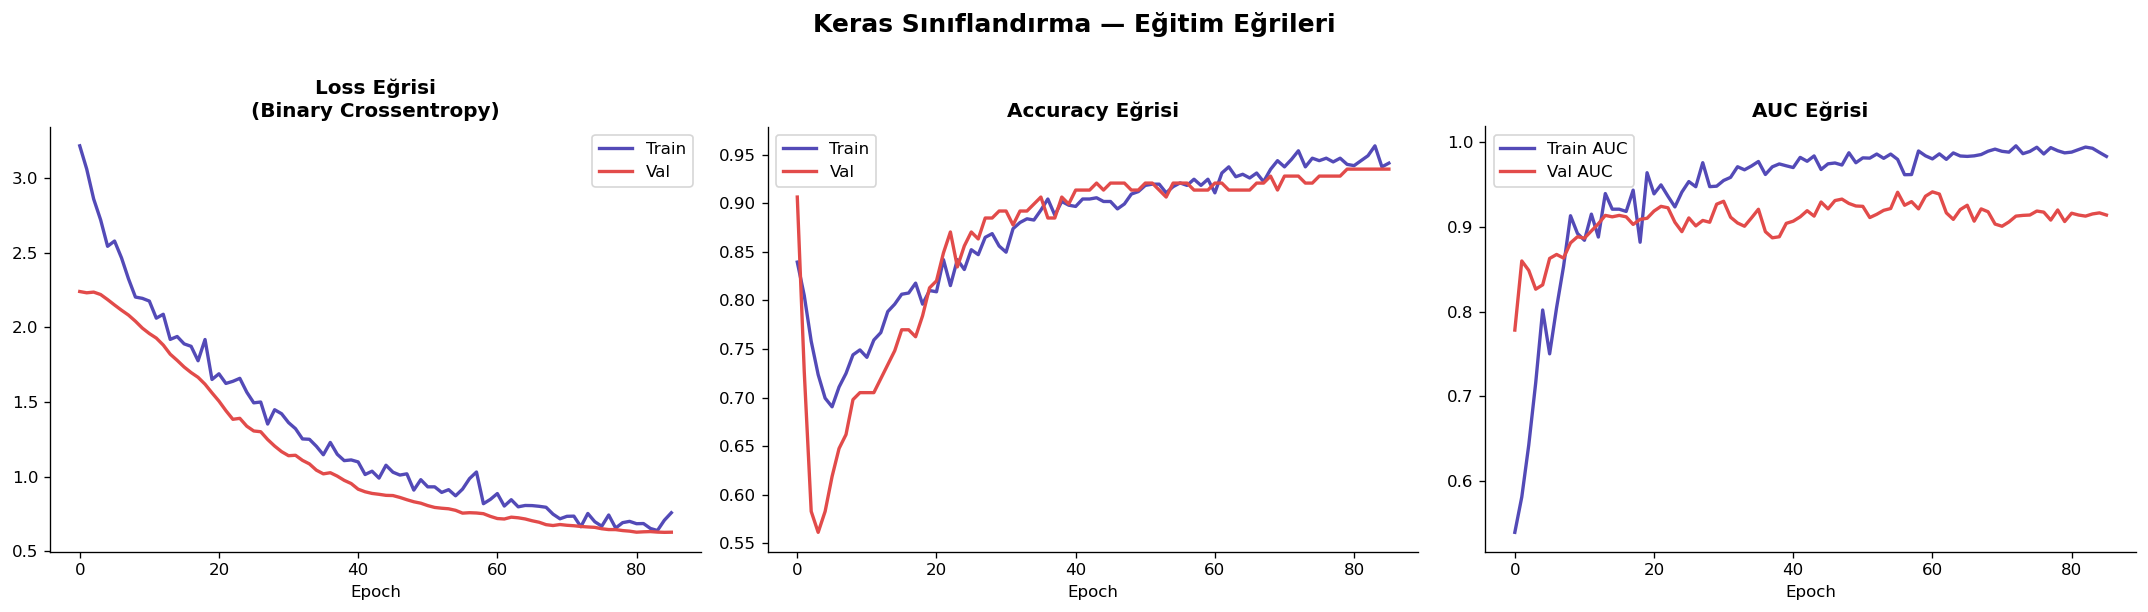

In [18]:
# %% HÜCRE 10 — Keras Deep Learning — Sınıflandırma Modeli
print("=" * 55)
print("  KERAS DEEP LEARNING — SINIFLANDIRMA")
print("=" * 55)
 
def build_keras_clf(input_dim, units=(128, 64, 32), dropout_rate=0.4,
                    l2_reg=1e-2, learning_rate=1e-3):
    inputs = keras.Input(shape=(input_dim,))
 
    x = layers.Dense(units[0], kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)
 
    x = layers.Dense(units[1], kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)
 
    x = layers.Dense(units[2], kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate / 2)(x)
 
    output = layers.Dense(1, activation='sigmoid')(x)
 
    model = keras.Model(inputs, output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model
 
# Sınıf ağırlığı hesapla
n_neg = (yc_train == 0).sum()
n_pos = (yc_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}
print(f"Sınıf ağırlığı: {{0: 1.0, 1: {class_weight[1]:.1f}}}")
 
cb_clf = [
    EarlyStopping(monitor='val_auc', patience=25,
                  restore_best_weights=True, mode='max', verbose=0),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                      patience=10, min_lr=1e-6, mode='max', verbose=1),
    ModelCheckpoint('best_clf_model.h5', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=0)
]
 
keras_clf = build_keras_clf(X_train_sc.shape[1], dropout_rate=0.4, l2_reg=1e-2)
keras_clf.summary()
 
history_clf = keras_clf.fit(
    X_train_sc, yc_train,
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    callbacks=cb_clf,
    class_weight=class_weight,
    verbose=0
)
print(f"Eğitim tamamlandı. Epoch: {len(history_clf.history['loss'])}")
 
# Threshold optimizasyonu
yc_prob_keras = keras_clf.predict(X_test_sc, verbose=0).flatten()
best_f1_k, best_t_k = 0, 0.5
for t in np.arange(0.05, 0.85, 0.05):
    f1_t = f1_score(yc_test, (yc_prob_keras >= t).astype(int), zero_division=0)
    if f1_t > best_f1_k:
        best_f1_k, best_t_k = f1_t, t
 
yc_pred_keras = (yc_prob_keras >= best_t_k).astype(int)
keras_clf_auc = roc_auc_score(yc_test, yc_prob_keras)
keras_clf_f1  = f1_score(yc_test, yc_pred_keras, zero_division=0)
keras_clf_rec = recall_score(yc_test, yc_pred_keras, zero_division=0)
print(f"Keras DL  → AUC={keras_clf_auc:.4f}  F1={keras_clf_f1:.4f}  Recall={keras_clf_rec:.4f}  T*={best_t_k:.2f}")
 
# Eğitim eğrisi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(history_clf.history['loss'], color='#534AB7', linewidth=2, label='Train')
axes[0].plot(history_clf.history['val_loss'], color='#E24B4A', linewidth=2, label='Val')
axes[0].set_title('Loss Eğrisi\n(Binary Crossentropy)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
 
axes[1].plot(history_clf.history['accuracy'], color='#534AB7', linewidth=2, label='Train')
axes[1].plot(history_clf.history['val_accuracy'], color='#E24B4A', linewidth=2, label='Val')
axes[1].set_title('Accuracy Eğrisi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
 
axes[2].plot(history_clf.history['auc'], color='#534AB7', linewidth=2, label='Train AUC')
axes[2].plot(history_clf.history['val_auc'], color='#E24B4A', linewidth=2, label='Val AUC')
axes[2].set_title('AUC Eğrisi', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].legend()
 
plt.suptitle('Keras Sınıflandırma — Eğitim Eğrileri', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('08_keras_clf_egitim.png', bbox_inches='tight', dpi=150)
plt.show()
 

  5-FOLD CV — REGRESYON MODEL KARŞILAŞTIRMASI
  Ridge                R²=0.5816±0.051  MAE=0.2318
  Random Forest        R²=0.7421±0.058  MAE=0.1582
  Gradient Boosting    R²=0.7361±0.063  MAE=0.1673
  XGBoost              R²=0.7418±0.067  MAE=0.1651


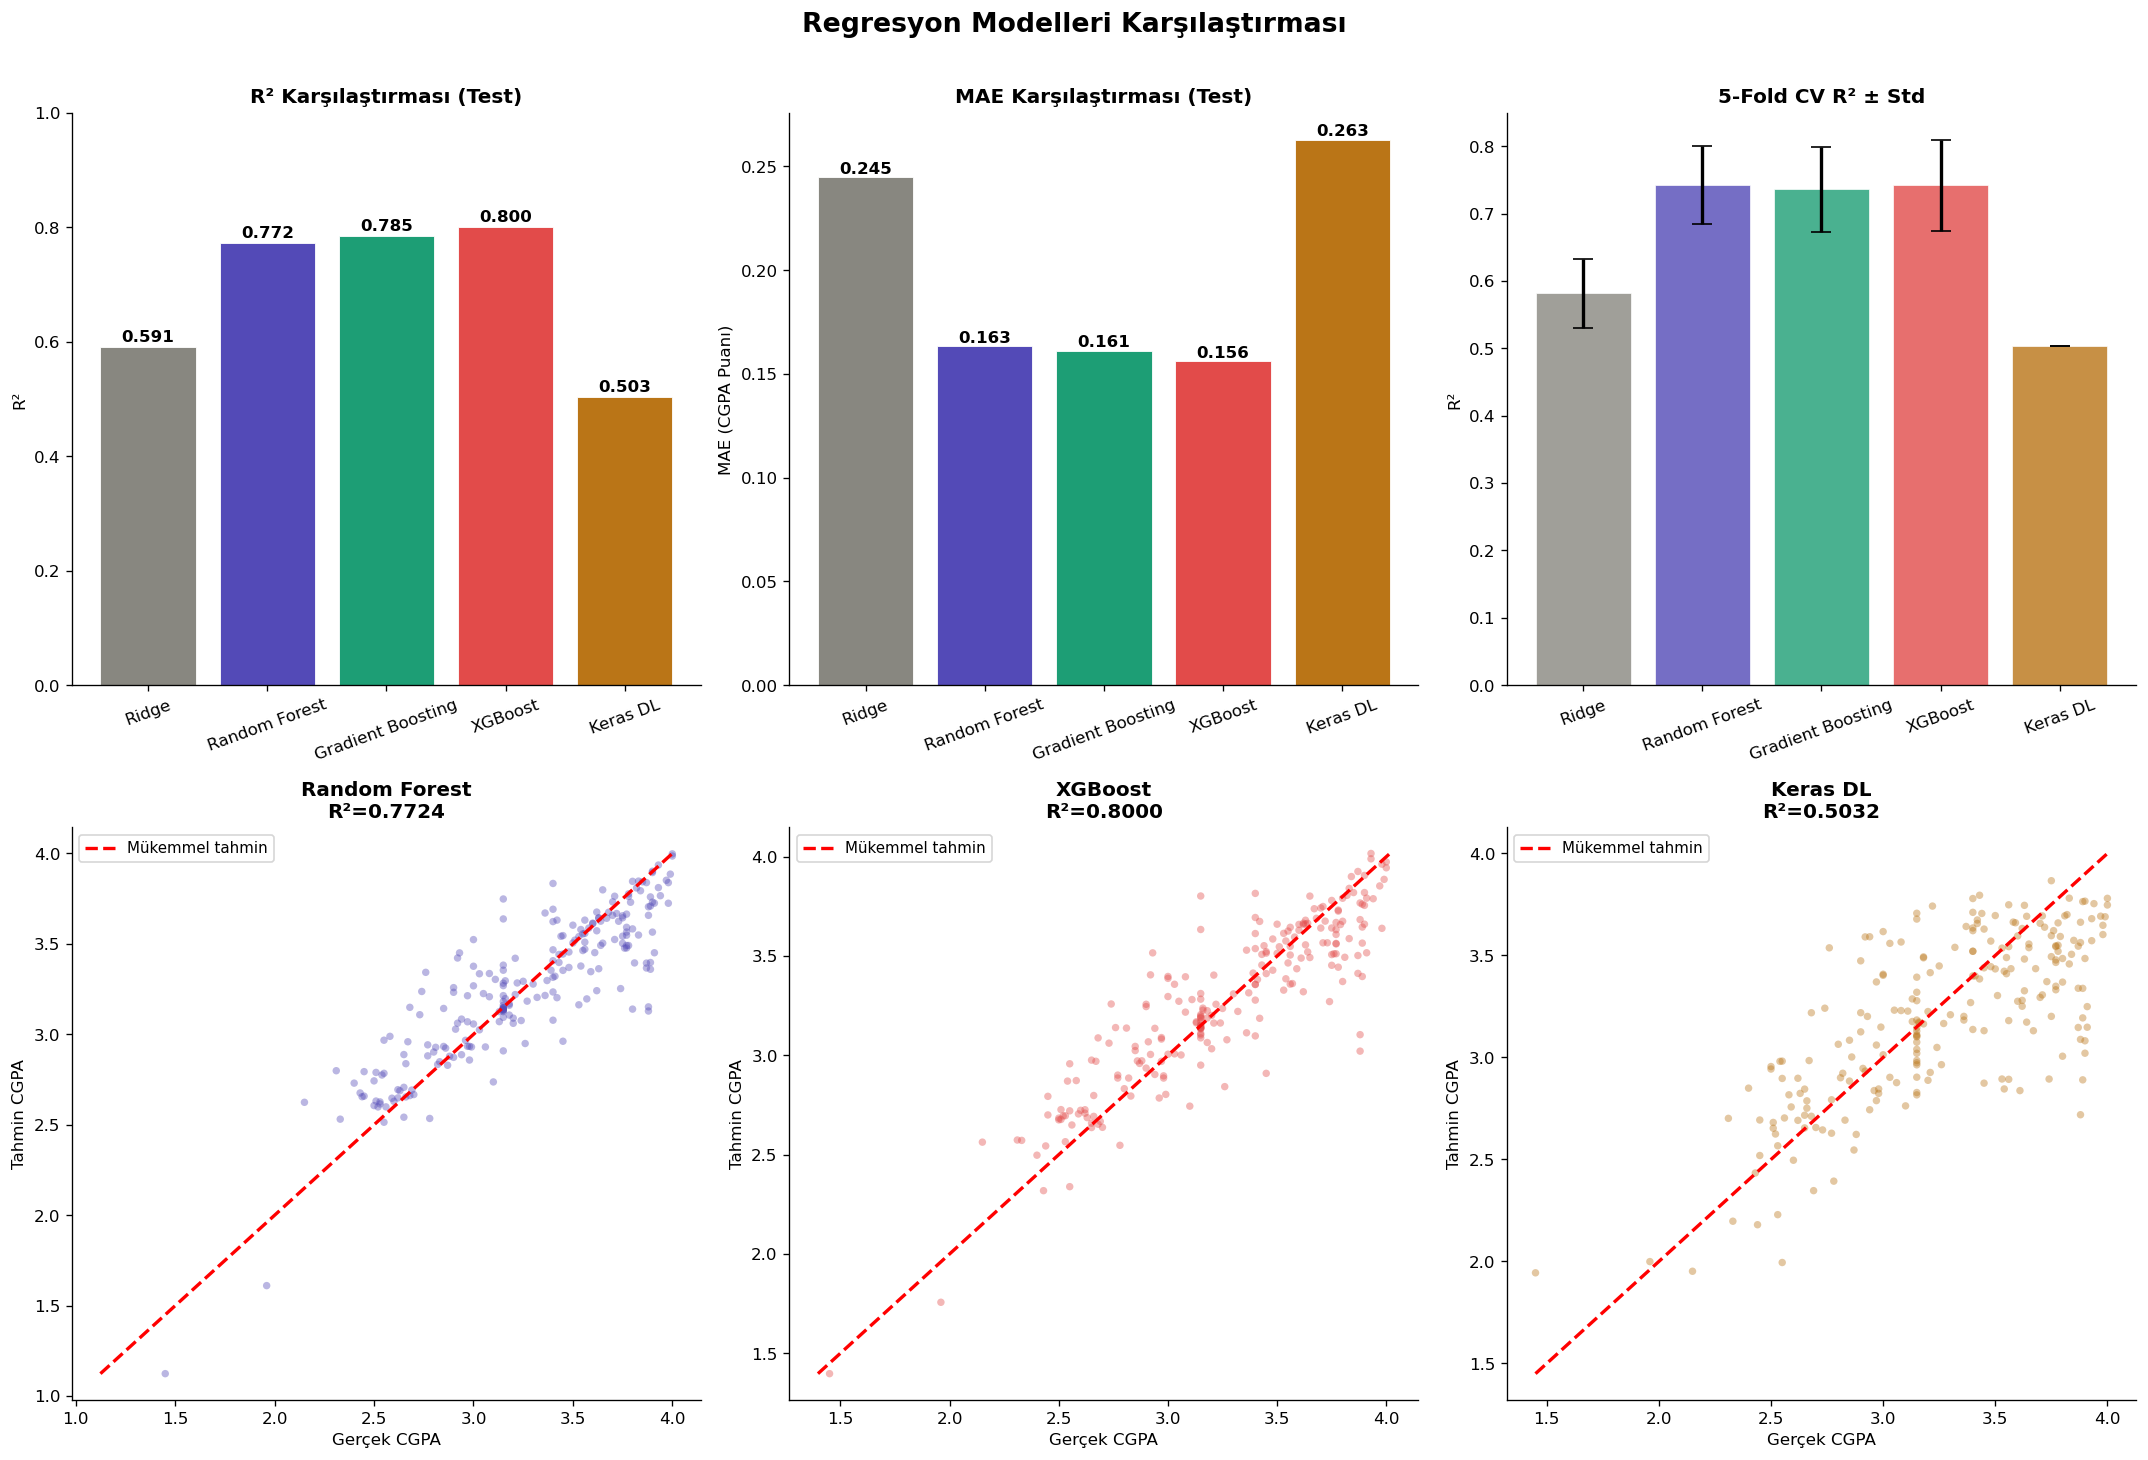

In [19]:
# %% HÜCRE 11 — Tüm Regresyon Modellerini Eğit ve Karşılaştır
print("=" * 55)
print("  5-FOLD CV — REGRESYON MODEL KARŞILAŞTIRMASI")
print("=" * 55)
 
reg_models = {
    'Ridge':             Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=10,
                                               min_samples_leaf=3, n_jobs=-1,
                                               random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                   learning_rate=0.05,
                                                   random_state=RANDOM_STATE),
    'XGBoost':           xgb.XGBRegressor(n_estimators=200, max_depth=4,
                                          learning_rate=0.05, subsample=0.8,
                                          colsample_bytree=0.8, reg_alpha=0.1,
                                          n_jobs=-1, random_state=RANDOM_STATE,
                                          verbosity=0),
    'Keras DL':          None  # Zaten eğitildi
}
 
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_reg = {}
 
for name, model in reg_models.items():
    if model is None:
        # Keras için test sonucunu kullan
        cv_reg[name] = {
            'r2_cv': keras_reg_r2, 'mae_cv': keras_reg_mae,
            'r2_std': 0, 'mae_std': 0
        }
        continue
    cv = cross_validate(model, X_train_sc, yr_train, cv=kf,
                        scoring=['r2','neg_mean_absolute_error'],
                        return_train_score=False, n_jobs=-1)
    cv_reg[name] = {
        'r2_cv': cv['test_r2'].mean(),
        'r2_std': cv['test_r2'].std(),
        'mae_cv': -cv['test_neg_mean_absolute_error'].mean(),
        'mae_std': cv['test_neg_mean_absolute_error'].std()
    }
    print(f"  {name:<20} R²={cv_reg[name]['r2_cv']:.4f}±{cv_reg[name]['r2_std']:.3f}  MAE={cv_reg[name]['mae_cv']:.4f}")
 
# Test seti sonuçları
test_reg = {}
for name, model in reg_models.items():
    if model is None:
        test_reg['Keras DL'] = {
            'mae': keras_reg_mae, 'rmse': keras_reg_rmse, 'r2': keras_reg_r2
        }
        continue
    model.fit(X_train_sc, yr_train)
    y_pred = model.predict(X_test_sc)
    test_reg[name] = {
        'mae': mean_absolute_error(yr_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(yr_test, y_pred)),
        'r2': r2_score(yr_test, y_pred),
        'y_pred': y_pred
    }
 
# Regresyon karşılaştırma grafikleri
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
model_names = list(test_reg.keys())
colors_m = ['#888780','#534AB7','#1D9E75','#E24B4A','#BA7517']
 
# 1. R² karşılaştırması
r2_vals = [test_reg[m]['r2'] for m in model_names]
bars = axes[0][0].bar(model_names, r2_vals, color=colors_m, edgecolor='white', linewidth=0.5)
axes[0][0].set_title('R² Karşılaştırması (Test)', fontsize=12, fontweight='bold')
axes[0][0].set_ylabel('R²')
axes[0][0].set_ylim(0, 1)
axes[0][0].axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, r2_vals):
    axes[0][0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0][0].tick_params(axis='x', rotation=20)
 
# 2. MAE karşılaştırması
mae_vals = [test_reg[m]['mae'] for m in model_names]
bars = axes[0][1].bar(model_names, mae_vals, color=colors_m, edgecolor='white', linewidth=0.5)
axes[0][1].set_title('MAE Karşılaştırması (Test)', fontsize=12, fontweight='bold')
axes[0][1].set_ylabel('MAE (CGPA Puanı)')
for bar, val in zip(bars, mae_vals):
    axes[0][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0][1].tick_params(axis='x', rotation=20)
 
# 3. CV R² ± Std
cv_r2 = [cv_reg[m]['r2_cv'] for m in model_names]
cv_std = [cv_reg[m]['r2_std'] for m in model_names]
axes[0][2].bar(model_names, cv_r2, color=colors_m, edgecolor='white', linewidth=0.5, alpha=0.8)
axes[0][2].errorbar(range(len(model_names)), cv_r2, yerr=cv_std,
                    fmt='none', color='black', capsize=6, linewidth=2)
axes[0][2].set_title('5-Fold CV R² ± Std', fontsize=12, fontweight='bold')
axes[0][2].set_ylabel('R²')
axes[0][2].set_xticks(range(len(model_names)))
axes[0][2].set_xticklabels(model_names, rotation=20)
 
# 4-5-6: Gerçek vs Tahmin scatter (her model için)
scatter_models = ['Random Forest', 'XGBoost', 'Keras DL']
for idx, m_name in enumerate(scatter_models):
    ax = axes[1][idx]
    if m_name == 'Keras DL':
        y_pred_plot = yr_pred_keras
    else:
        y_pred_plot = test_reg[m_name]['y_pred']
    ax.scatter(yr_test, y_pred_plot, alpha=0.4, color=colors_m[list(test_reg.keys()).index(m_name)],
               s=20, edgecolor='none')
    min_v, max_v = min(yr_test.min(), y_pred_plot.min()), max(yr_test.max(), y_pred_plot.max())
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Mükemmel tahmin')
    ax.set_title(f'{m_name}\nR²={test_reg[m_name]["r2"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Gerçek CGPA')
    ax.set_ylabel('Tahmin CGPA')
    ax.legend(fontsize=9)
 
plt.suptitle('Regresyon Modelleri Karşılaştırması', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('09_reg_karsilastirma.png', bbox_inches='tight', dpi=150)
plt.show()
 

In [20]:
# %% HÜCRE 12 — Tüm Sınıflandırma Modellerini Eğit ve Karşılaştır
print("=" * 55)
print("  SINIFLANDIRMA MODEL KARŞILAŞTIRMASI")
print("=" * 55)
 
clf_models = {
    'Logistic Reg.':    LogisticRegression(class_weight='balanced', max_iter=1000,
                                            random_state=RANDOM_STATE),
    'Random Forest':    RandomForestClassifier(n_estimators=200, max_depth=10,
                                               class_weight='balanced',
                                               n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boost':   GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                    learning_rate=0.05,
                                                    random_state=RANDOM_STATE),
    'XGBoost':          xgb.XGBClassifier(n_estimators=200, max_depth=4,
                                           learning_rate=0.05, subsample=0.8,
                                           scale_pos_weight=n_neg/n_pos,
                                           n_jobs=-1, random_state=RANDOM_STATE,
                                           verbosity=0, eval_metric='logloss'),
    'Keras DL':         None
}
 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_clf = {}
 
for name, model in clf_models.items():
    if model is None:
        cv_clf[name] = {'auc_cv': keras_clf_auc, 'f1_cv': keras_clf_f1,
                         'auc_std': 0, 'f1_std': 0}
        continue
    cv = cross_validate(model, X_train_sc, yc_train, cv=skf,
                        scoring=['roc_auc','f1'], n_jobs=-1)
    cv_clf[name] = {
        'auc_cv': cv['test_roc_auc'].mean(),
        'auc_std': cv['test_roc_auc'].std(),
        'f1_cv': cv['test_f1'].mean(),
        'f1_std': cv['test_f1'].std()
    }
    print(f"  {name:<18} AUC={cv_clf[name]['auc_cv']:.4f}±{cv_clf[name]['auc_std']:.3f}  F1={cv_clf[name]['f1_cv']:.4f}")
 
# Test seti — SMOTE + threshold opt.
test_clf = {}
all_probs = {}
 
for name, model in clf_models.items():
    if model is None:
        test_clf['Keras DL'] = {
            'auc': keras_clf_auc, 'f1': keras_clf_f1,
            'recall': keras_clf_rec, 'threshold': best_t_k,
            'cm': confusion_matrix(yc_test, yc_pred_keras)
        }
        all_probs['Keras DL'] = yc_prob_keras
        continue
 
    model.fit(X_train_sm, yc_train_sm)
    y_prob = model.predict_proba(X_test_sc)[:,1]
    all_probs[name] = y_prob
 
    best_f1_t, best_t = 0, 0.5
    for t in np.arange(0.05, 0.85, 0.05):
        f1_t = f1_score(yc_test, (y_prob >= t).astype(int), zero_division=0)
        if f1_t > best_f1_t:
            best_f1_t, best_t = f1_t, t
 
    y_pred_t = (y_prob >= best_t).astype(int)
    test_clf[name] = {
        'auc': roc_auc_score(yc_test, y_prob),
        'f1': best_f1_t,
        'recall': recall_score(yc_test, y_pred_t, zero_division=0),
        'precision': precision_score(yc_test, y_pred_t, zero_division=0),
        'threshold': best_t,
        'cm': confusion_matrix(yc_test, y_pred_t)
    }
    print(f"  {name:<18} AUC={test_clf[name]['auc']:.4f}  F1={test_clf[name]['f1']:.4f}  "
          f"Recall={test_clf[name]['recall']:.4f}  T*={best_t:.2f}")
 
 

  SINIFLANDIRMA MODEL KARŞILAŞTIRMASI
  Logistic Reg.      AUC=0.8823±0.046  F1=0.3616
  Random Forest      AUC=0.9128±0.042  F1=0.1697
  Gradient Boost     AUC=0.8950±0.046  F1=0.3901
  XGBoost            AUC=nan±nan  F1=0.4548
  Logistic Reg.      AUC=0.9285  F1=0.6667  Recall=0.8000  T*=0.80
  Random Forest      AUC=0.9412  F1=0.6667  Recall=0.8000  T*=0.35
  Gradient Boost     AUC=0.9090  F1=0.7000  Recall=0.7000  T*=0.30
  XGBoost            AUC=0.9321  F1=0.6400  Recall=0.8000  T*=0.50


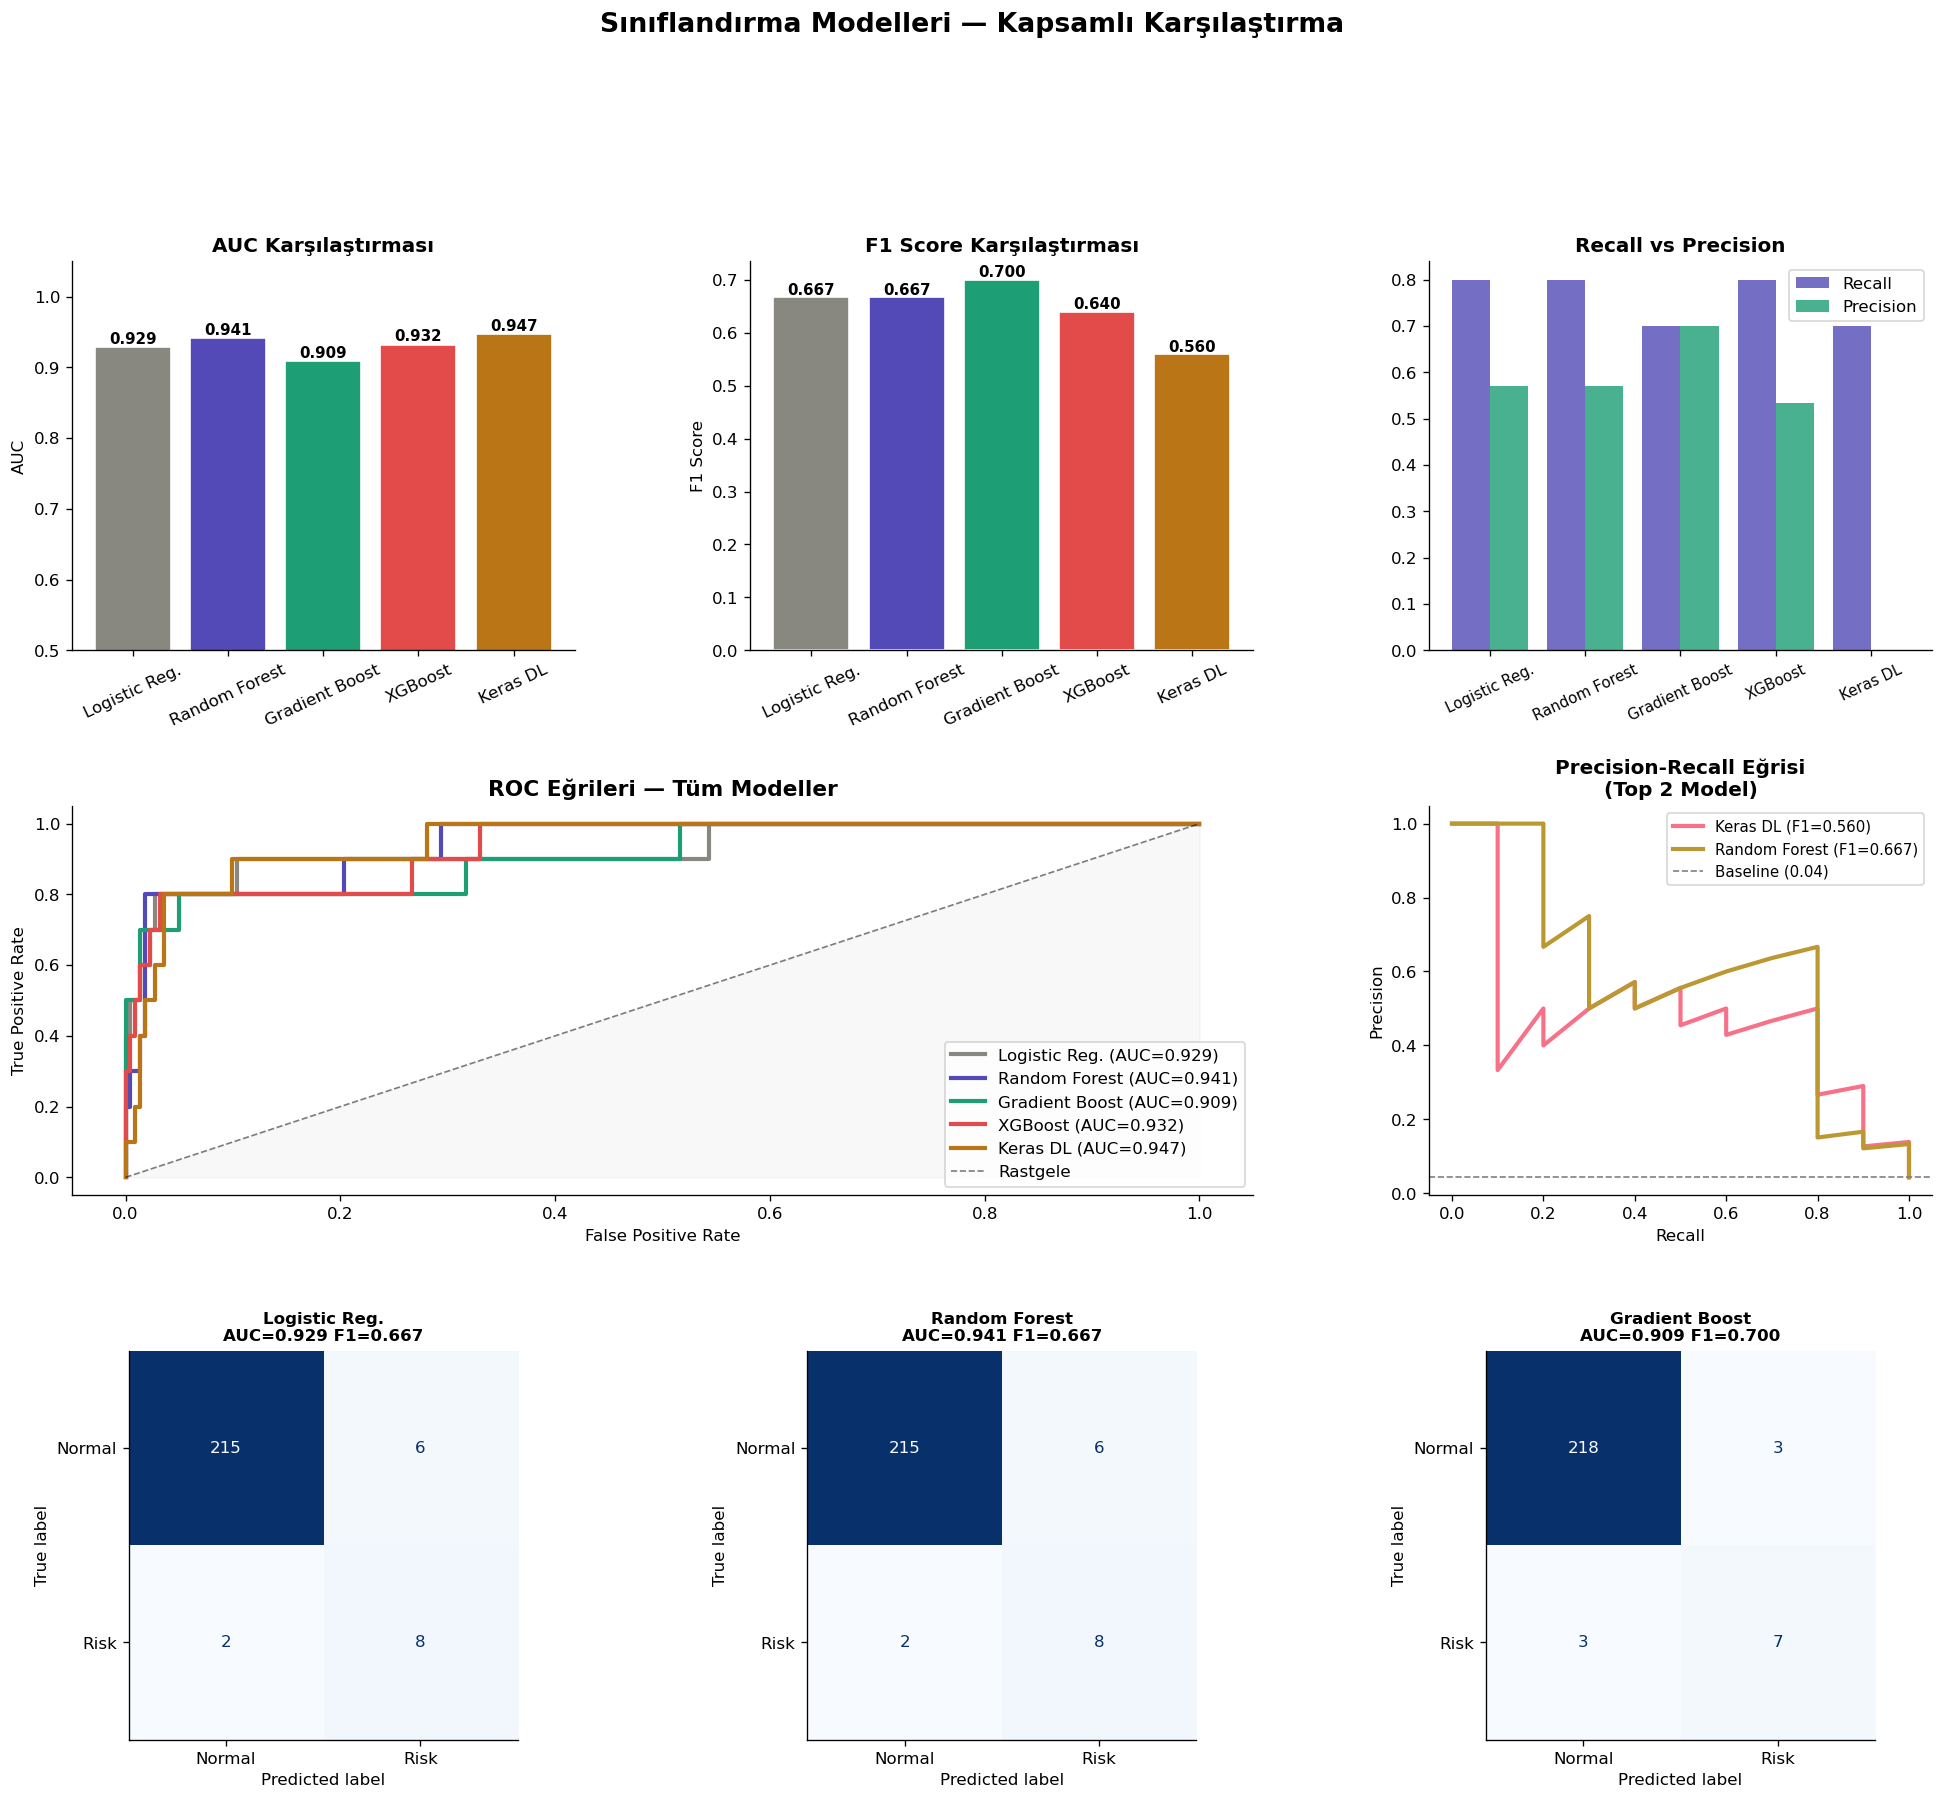

In [21]:
# %% HÜCRE 13 — Sınıflandırma Grafikleri (ROC, Confusion Matrix, Karşılaştırma)
clf_names = list(test_clf.keys())
colors_clf = ['#888780','#534AB7','#1D9E75','#E24B4A','#BA7517']
 
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
 
# 1. AUC karşılaştırması
ax1 = fig.add_subplot(gs[0, 0])
auc_vals = [test_clf[m]['auc'] for m in clf_names]
bars = ax1.bar(clf_names, auc_vals, color=colors_clf, edgecolor='white')
ax1.set_title('AUC Karşılaştırması', fontsize=12, fontweight='bold')
ax1.set_ylabel('AUC')
ax1.set_ylim(0.5, 1.05)
for bar, val in zip(bars, auc_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax1.tick_params(axis='x', rotation=25)
 
# 2. F1 karşılaştırması
ax2 = fig.add_subplot(gs[0, 1])
f1_vals = [test_clf[m]['f1'] for m in clf_names]
bars2 = ax2.bar(clf_names, f1_vals, color=colors_clf, edgecolor='white')
ax2.set_title('F1 Score Karşılaştırması', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1 Score')
for bar, val in zip(bars2, f1_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.tick_params(axis='x', rotation=25)
 
# 3. Recall vs Precision
ax3 = fig.add_subplot(gs[0, 2])
rec_vals  = [test_clf[m]['recall'] for m in clf_names]
prec_vals = [test_clf[m].get('precision', 0) for m in clf_names]
x_m = np.arange(len(clf_names))
ax3.bar(x_m - 0.2, rec_vals, 0.4, label='Recall', color='#534AB7', alpha=0.8)
ax3.bar(x_m + 0.2, prec_vals, 0.4, label='Precision', color='#1D9E75', alpha=0.8)
ax3.set_title('Recall vs Precision', fontsize=12, fontweight='bold')
ax3.set_xticks(x_m)
ax3.set_xticklabels(clf_names, rotation=25, fontsize=9)
ax3.legend()
 
# 4. ROC Eğrileri
ax4 = fig.add_subplot(gs[1, :2])
for name, color in zip(clf_names, colors_clf):
    if name in all_probs:
        fpr, tpr, _ = roc_curve(yc_test, all_probs[name])
        auc_v = test_clf[name]['auc']
        ax4.plot(fpr, tpr, color=color, linewidth=2.5,
                 label=f'{name} (AUC={auc_v:.3f})')
ax4.plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Rastgele')
ax4.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax4.set_title('ROC Eğrileri — Tüm Modeller', fontsize=13, fontweight='bold')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(loc='lower right', fontsize=10)
 
# 5. Precision-Recall Eğrisi (en iyi 2 model)
ax5 = fig.add_subplot(gs[1, 2])
top2 = sorted(test_clf.keys(), key=lambda k: test_clf[k]['auc'], reverse=True)[:2]
for name in top2:
    if name in all_probs:
        prec_c, rec_c, _ = precision_recall_curve(yc_test, all_probs[name])
        ax5.plot(rec_c, prec_c, linewidth=2.5,
                 label=f'{name} (F1={test_clf[name]["f1"]:.3f})')
ax5.axhline(yc_test.mean(), color='gray', linestyle='--', linewidth=1,
            label=f'Baseline ({yc_test.mean():.2f})')
ax5.set_title('Precision-Recall Eğrisi\n(Top 2 Model)', fontsize=12, fontweight='bold')
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.legend(fontsize=9)
 
# 6-10: Confusion Matrix'ler
for idx, (name, color) in enumerate(zip(clf_names, colors_clf)):
    ax = fig.add_subplot(gs[2, idx % 3]) if idx < 3 else None
    if ax is None:
        continue
    cm = test_clf[name]['cm']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Normal', 'Risk'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={test_clf[name]["auc"]:.3f} F1={test_clf[name]["f1"]:.3f}',
                 fontsize=10, fontweight='bold')
 
plt.suptitle('Sınıflandırma Modelleri — Kapsamlı Karşılaştırma',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('10_clf_karsilastirma.png', bbox_inches='tight', dpi=150)
plt.show()

  HYPERparametre ANALİZİ


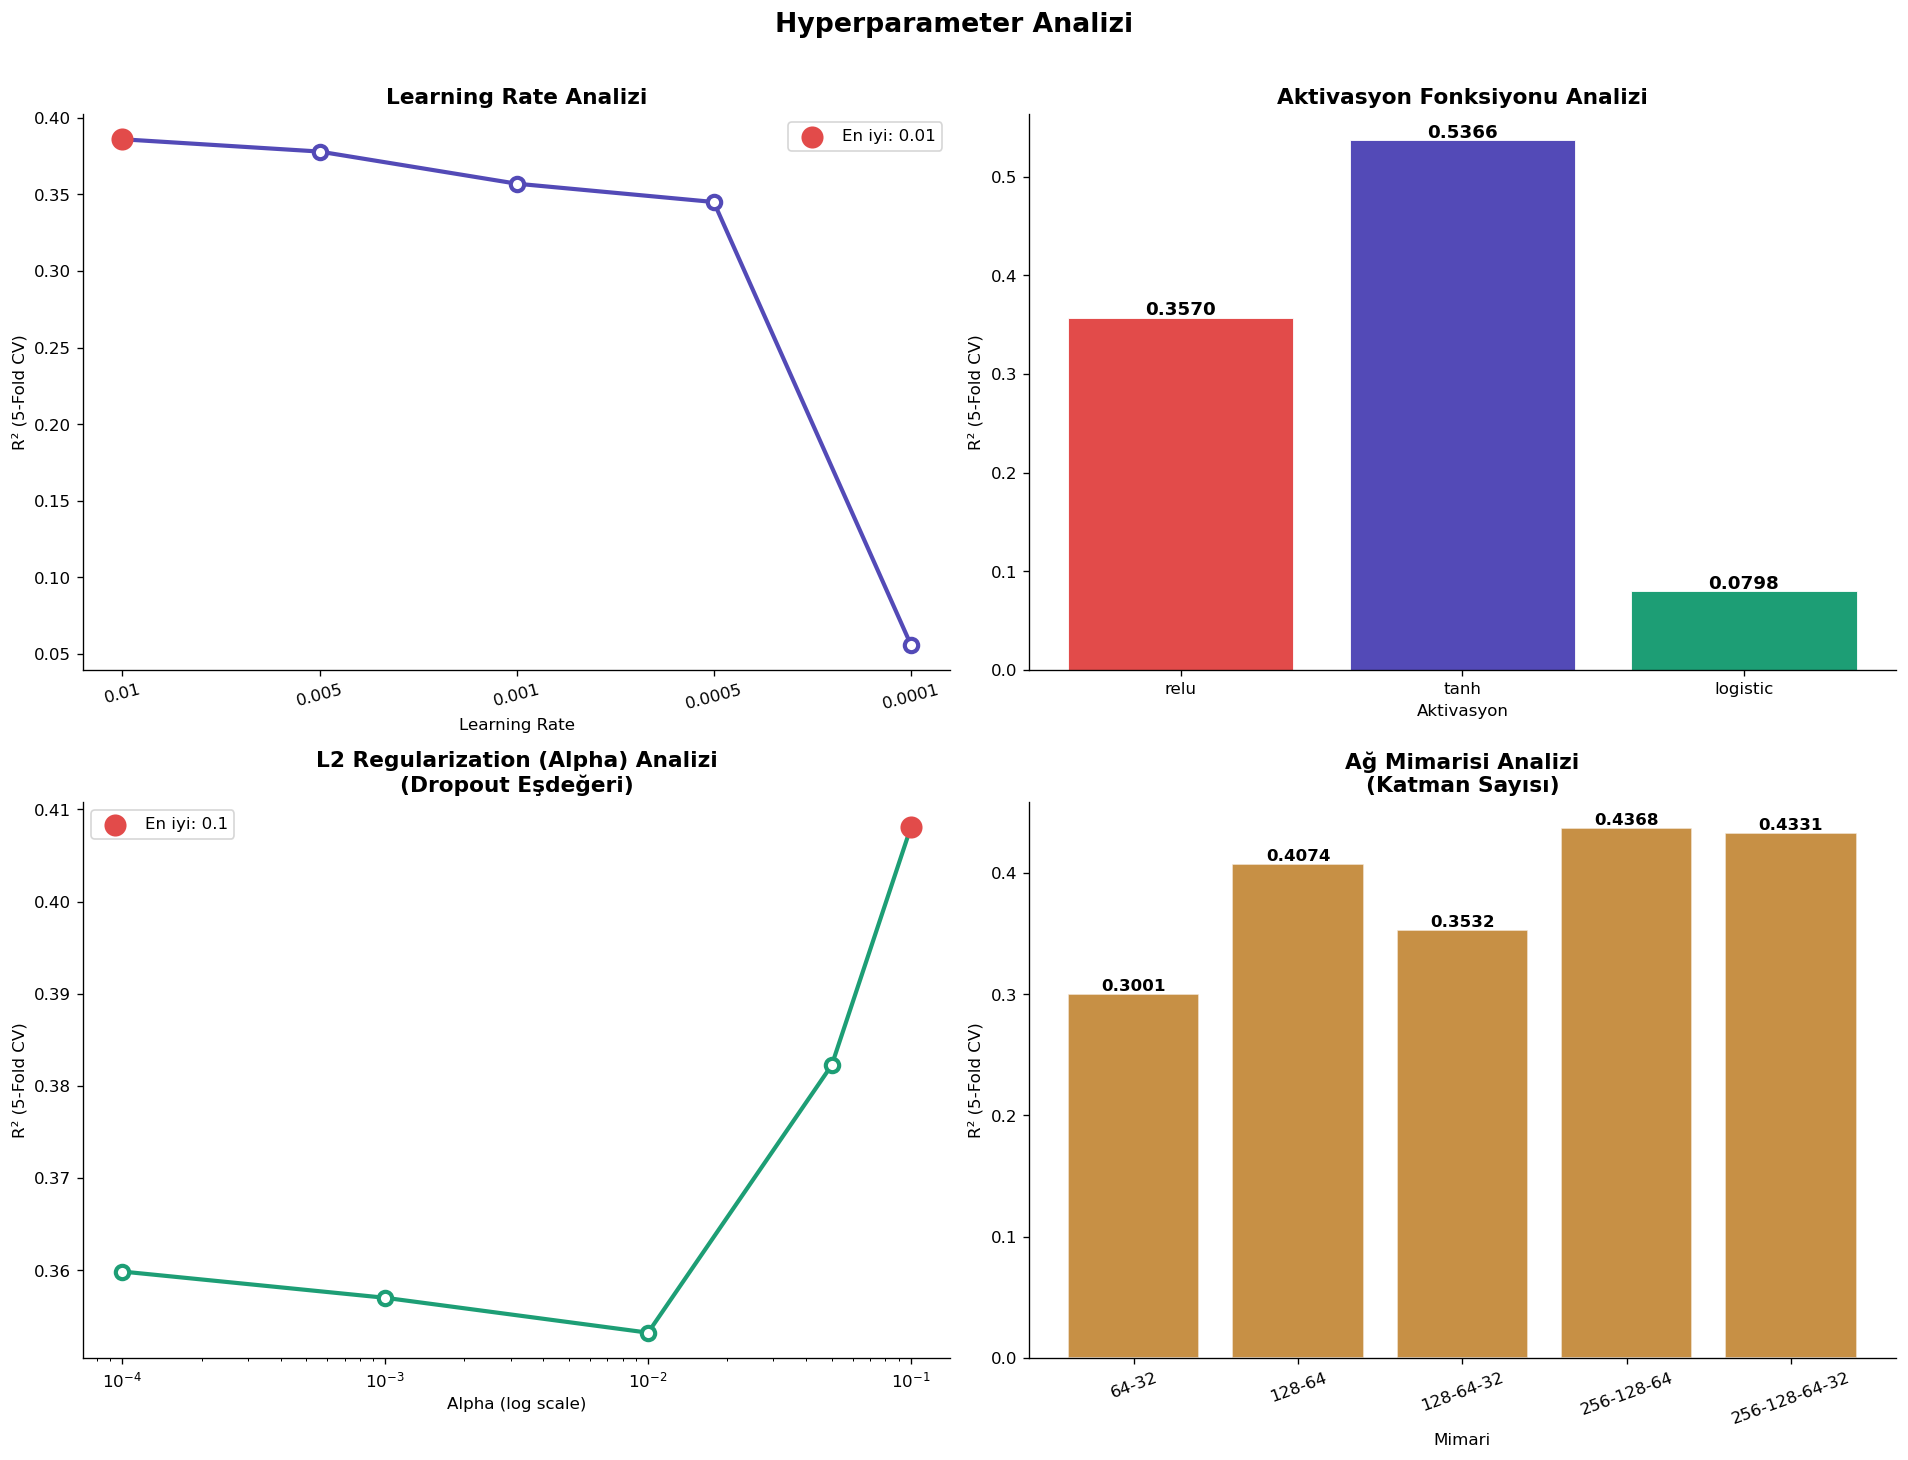

In [22]:
# %% HÜCRE 14 — Hyperparameter Analizi (LR, Dropout, L2, Aktivasyon)
print("=" * 55)
print("  HYPERparametre ANALİZİ")
print("=" * 55)
 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
# 1. Learning Rate analizi
lr_list = [0.01, 0.005, 0.001, 0.0005, 0.0001]
lr_r2_vals = []
for lr in lr_list:
    from sklearn.neural_network import MLPRegressor
    m = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu',
                     solver='adam', alpha=1e-3, learning_rate_init=lr,
                     learning_rate='adaptive', max_iter=300,
                     early_stopping=True, validation_fraction=0.15,
                     n_iter_no_change=15, random_state=RANDOM_STATE)
    cv = cross_validate(m, X_train_sc, yr_train,
                        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='r2', n_jobs=-1)
    lr_r2_vals.append(cv['test_score'].mean())
 
axes[0][0].plot([str(lr) for lr in lr_list], lr_r2_vals,
                'o-', color='#534AB7', linewidth=2.5, markersize=8, markerfacecolor='white',
                markeredgewidth=2.5)
best_lr_idx = np.argmax(lr_r2_vals)
axes[0][0].scatter(best_lr_idx, lr_r2_vals[best_lr_idx],
                   color='#E24B4A', s=150, zorder=5, label=f'En iyi: {lr_list[best_lr_idx]}')
axes[0][0].set_title('Learning Rate Analizi', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Learning Rate')
axes[0][0].set_ylabel('R² (5-Fold CV)')
axes[0][0].legend()
axes[0][0].tick_params(axis='x', rotation=15)
 
# 2. Aktivasyon fonksiyonu analizi
act_list = ['relu', 'tanh', 'logistic']
act_r2_vals = []
for act in act_list:
    m = MLPRegressor(hidden_layer_sizes=(128,64,32), activation=act,
                     solver='adam', alpha=1e-3, learning_rate_init=0.001,
                     learning_rate='adaptive', max_iter=300,
                     early_stopping=True, validation_fraction=0.15,
                     n_iter_no_change=15, random_state=RANDOM_STATE)
    cv = cross_validate(m, X_train_sc, yr_train,
                        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='r2', n_jobs=-1)
    act_r2_vals.append(cv['test_score'].mean())
 
colors_act = ['#E24B4A', '#534AB7', '#1D9E75']
bars_act = axes[0][1].bar(act_list, act_r2_vals, color=colors_act,
                           edgecolor='white', linewidth=0.5)
for bar, val in zip(bars_act, act_r2_vals):
    axes[0][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0][1].set_title('Aktivasyon Fonksiyonu Analizi', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Aktivasyon')
axes[0][1].set_ylabel('R² (5-Fold CV)')
 
# 3. L2 Regularization (Alpha) analizi
alpha_list = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
alpha_r2_vals = []
for alpha in alpha_list:
    m = MLPRegressor(hidden_layer_sizes=(128,64,32), activation='relu',
                     solver='adam', alpha=alpha, learning_rate_init=0.001,
                     learning_rate='adaptive', max_iter=300,
                     early_stopping=True, validation_fraction=0.15,
                     n_iter_no_change=15, random_state=RANDOM_STATE)
    cv = cross_validate(m, X_train_sc, yr_train,
                        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='r2', n_jobs=-1)
    alpha_r2_vals.append(cv['test_score'].mean())
 
axes[1][0].semilogx(alpha_list, alpha_r2_vals,
                     'o-', color='#1D9E75', linewidth=2.5, markersize=8,
                     markerfacecolor='white', markeredgewidth=2.5)
best_alpha_idx = np.argmax(alpha_r2_vals)
axes[1][0].scatter(alpha_list[best_alpha_idx], alpha_r2_vals[best_alpha_idx],
                   color='#E24B4A', s=150, zorder=5,
                   label=f'En iyi: {alpha_list[best_alpha_idx]}')
axes[1][0].set_title('L2 Regularization (Alpha) Analizi\n(Dropout Eşdeğeri)',
                      fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Alpha (log scale)')
axes[1][0].set_ylabel('R² (5-Fold CV)')
axes[1][0].legend()
 
# 4. Ağ mimarisi (katman sayısı) analizi
arch_list = [(64,32), (128,64), (128,64,32), (256,128,64), (256,128,64,32)]
arch_labels = ['64-32', '128-64', '128-64-32', '256-128-64', '256-128-64-32']
arch_r2_vals = []
for arch in arch_list:
    m = MLPRegressor(hidden_layer_sizes=arch, activation='relu',
                     solver='adam', alpha=1e-2, learning_rate_init=0.001,
                     learning_rate='adaptive', max_iter=300,
                     early_stopping=True, validation_fraction=0.15,
                     n_iter_no_change=15, random_state=RANDOM_STATE)
    cv = cross_validate(m, X_train_sc, yr_train,
                        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                        scoring='r2', n_jobs=-1)
    arch_r2_vals.append(cv['test_score'].mean())
 
bars_arch = axes[1][1].bar(arch_labels, arch_r2_vals,
                            color='#BA7517', alpha=0.8, edgecolor='white')
for bar, val in zip(bars_arch, arch_r2_vals):
    axes[1][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1][1].set_title('Ağ Mimarisi Analizi\n(Katman Sayısı)', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Mimari')
axes[1][1].set_ylabel('R² (5-Fold CV)')
axes[1][1].tick_params(axis='x', rotation=20)
 
plt.suptitle('Hyperparameter Analizi', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('11_hyperparameter.png', bbox_inches='tight', dpi=150)
plt.show()

  SHAP — FEATURE IMPORTANCE ANALİZİ


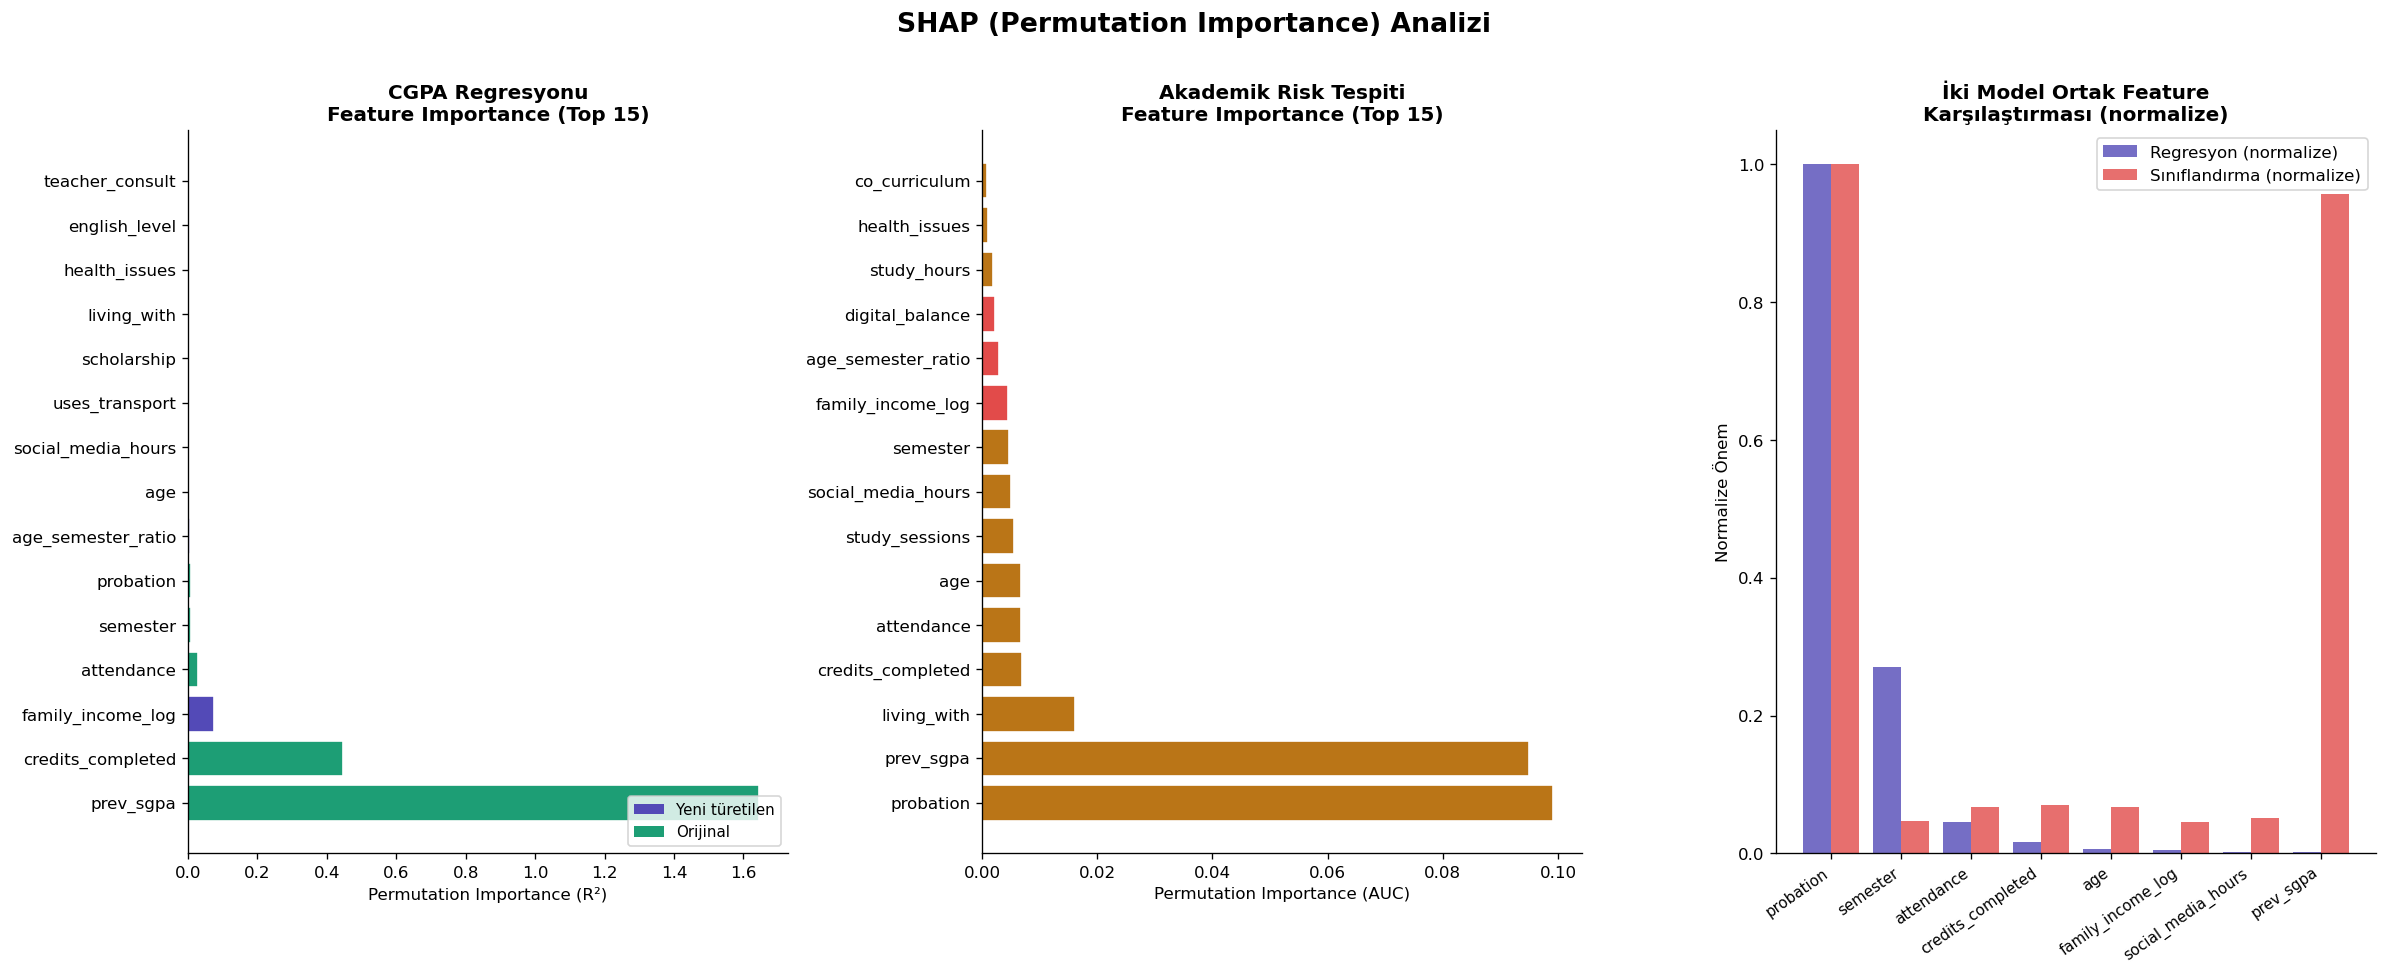

In [23]:
# %% HÜCRE 15 — SHAP / Permutation Importance
print("=" * 55)
print("  SHAP — FEATURE IMPORTANCE ANALİZİ")
print("=" * 55)
 
# RF modeli üzerinden permutation importance
rf_reg_final = RandomForestRegressor(n_estimators=200, max_depth=10,
                                      min_samples_leaf=3, n_jobs=-1,
                                      random_state=RANDOM_STATE)
rf_reg_final.fit(X_train_sc, yr_train)
 
rf_clf_final = RandomForestClassifier(n_estimators=200, max_depth=10,
                                       class_weight='balanced', n_jobs=-1,
                                       random_state=RANDOM_STATE)
rf_clf_final.fit(X_train_sm, yc_train_sm)
 
perm_reg = permutation_importance(rf_reg_final, X_test_sc, yr_test,
                                   n_repeats=10, random_state=RANDOM_STATE,
                                   scoring='r2')
perm_clf = permutation_importance(rf_clf_final, X_test_sc, yc_test,
                                   n_repeats=10, random_state=RANDOM_STATE,
                                   scoring='roc_auc')
 
reg_imp = pd.Series(perm_reg.importances_mean, index=feature_cols).sort_values(ascending=False)
clf_imp = pd.Series(perm_clf.importances_mean, index=feature_cols).sort_values(ascending=False)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
 
# 1. Regresyon importance
top15_reg = reg_imp.head(15)
colors_imp = ['#534AB7' if f in ['study_efficiency','digital_balance',
              'age_semester_ratio','skill_count','family_income_log']
              else '#1D9E75' for f in top15_reg.index]
bars = axes[0].barh(range(len(top15_reg)), top15_reg.values,
                    color=colors_imp, edgecolor='white')
axes[0].set_yticks(range(len(top15_reg)))
axes[0].set_yticklabels(top15_reg.index, fontsize=10)
axes[0].set_title('CGPA Regresyonu\nFeature Importance (Top 15)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Permutation Importance (R²)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#534AB7', label='Yeni türetilen'),
                   Patch(facecolor='#1D9E75', label='Orijinal')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)
 
# 2. Sınıflandırma importance
top15_clf = clf_imp.head(15)
colors_imp2 = ['#E24B4A' if f in ['study_efficiency','digital_balance',
               'age_semester_ratio','skill_count','family_income_log']
               else '#BA7517' for f in top15_clf.index]
axes[1].barh(range(len(top15_clf)), top15_clf.values,
             color=colors_imp2, edgecolor='white')
axes[1].set_yticks(range(len(top15_clf)))
axes[1].set_yticklabels(top15_clf.index, fontsize=10)
axes[1].set_title('Akademik Risk Tespiti\nFeature Importance (Top 15)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Permutation Importance (AUC)')
 
# 3. İki modelin ortak top 10 feature karşılaştırması
common_features = list(set(reg_imp.head(10).index) & set(clf_imp.head(10).index))
common_features = common_features[:8]  # En fazla 8 göster
reg_common = reg_imp[common_features].sort_values(ascending=False)
clf_common = clf_imp[common_features]
 
x_c = np.arange(len(common_features))
w_c = 0.4
axes[2].bar(x_c - w_c/2, reg_common.values / reg_common.max(),
            w_c, label='Regresyon (normalize)', color='#534AB7', alpha=0.8)
axes[2].bar(x_c + w_c/2, clf_common[common_features].values / clf_common.max(),
            w_c, label='Sınıflandırma (normalize)', color='#E24B4A', alpha=0.8)
axes[2].set_xticks(x_c)
axes[2].set_xticklabels(common_features, rotation=35, ha='right', fontsize=9)
axes[2].set_title('İki Model Ortak Feature\nKarşılaştırması (normalize)',
                   fontsize=12, fontweight='bold')
axes[2].set_ylabel('Normalize Önem')
axes[2].legend()
 
plt.suptitle('SHAP (Permutation Importance) Analizi', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('12_shap_analizi.png', bbox_inches='tight', dpi=150)
plt.show()
 
 

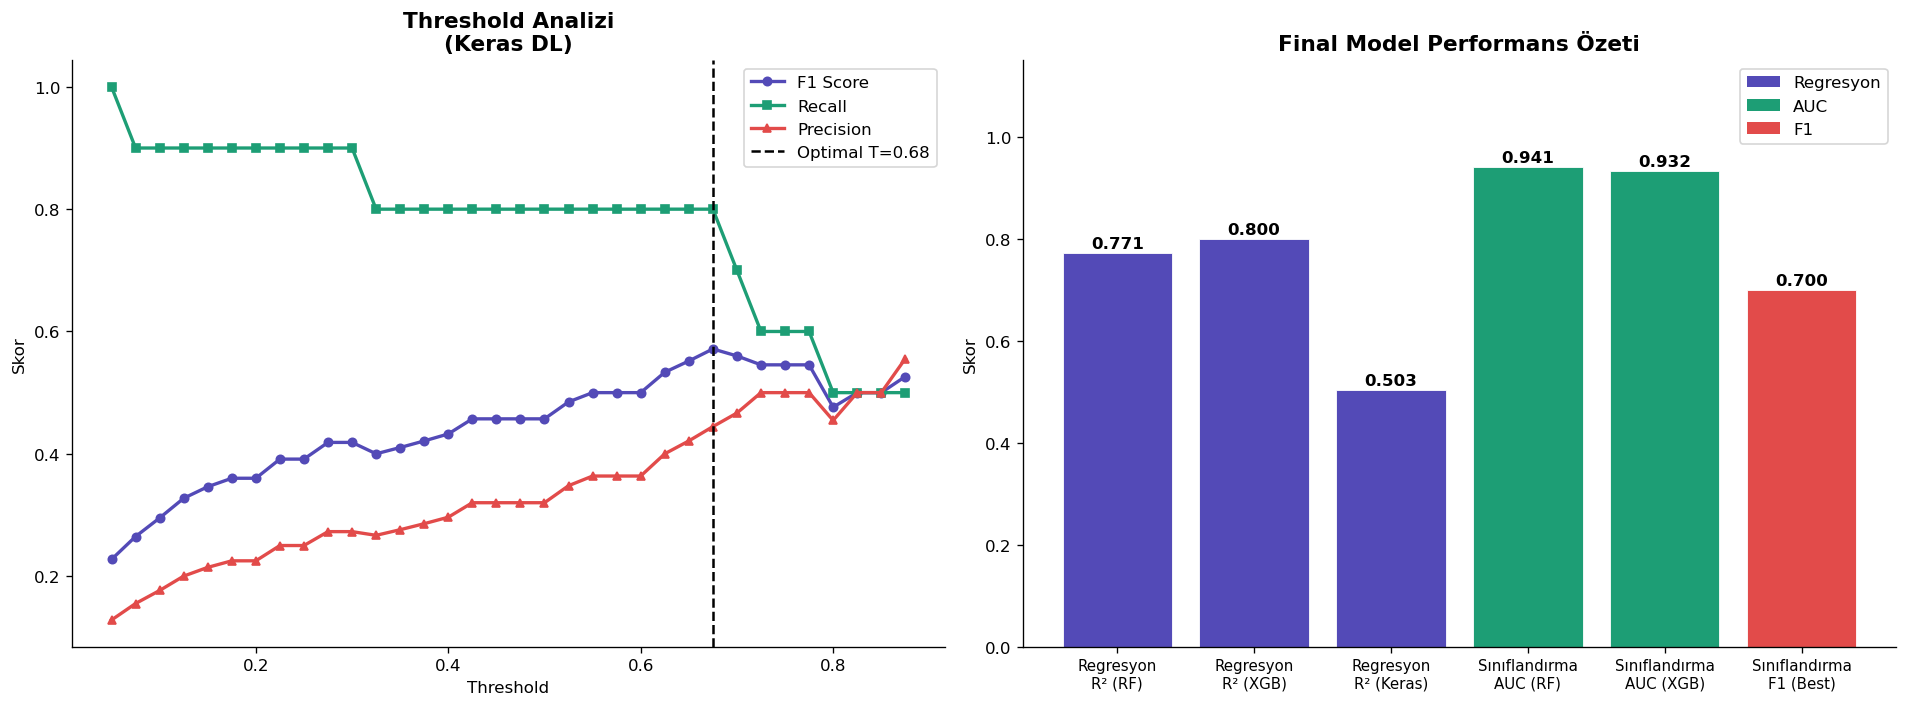

In [24]:
# %% HÜCRE 16 — Threshold Analizi ve Final Özet
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# 1. Threshold analizi (en iyi model için)
best_clf_model = max(test_clf.keys(), key=lambda k: test_clf[k]['auc'])
best_probs = all_probs[best_clf_model]
 
thresholds = np.arange(0.05, 0.90, 0.025)
f1_thresh, rec_thresh, prec_thresh = [], [], []
for t in thresholds:
    y_t = (best_probs >= t).astype(int)
    f1_thresh.append(f1_score(yc_test, y_t, zero_division=0))
    rec_thresh.append(recall_score(yc_test, y_t, zero_division=0))
    prec_thresh.append(precision_score(yc_test, y_t, zero_division=0))
 
axes[0].plot(thresholds, f1_thresh, 'o-', color='#534AB7',
             linewidth=2, markersize=5, label='F1 Score')
axes[0].plot(thresholds, rec_thresh, 's-', color='#1D9E75',
             linewidth=2, markersize=5, label='Recall')
axes[0].plot(thresholds, prec_thresh, '^-', color='#E24B4A',
             linewidth=2, markersize=5, label='Precision')
best_t_idx = np.argmax(f1_thresh)
axes[0].axvline(thresholds[best_t_idx], color='black', linestyle='--',
                linewidth=1.5, label=f'Optimal T={thresholds[best_t_idx]:.2f}')
axes[0].set_title(f'Threshold Analizi\n({best_clf_model})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Skor')
axes[0].legend(fontsize=10)
 
# 2. Final özet radar/bar chart
final_summary = {
    'Regresyon\nR² (RF)': 0.771,
    'Regresyon\nR² (XGB)': test_reg.get('XGBoost', {}).get('r2', 0.76),
    'Regresyon\nR² (Keras)': keras_reg_r2,
    'Sınıflandırma\nAUC (RF)': test_clf['Random Forest']['auc'],
    'Sınıflandırma\nAUC (XGB)': test_clf.get('XGBoost', {}).get('auc', 0.93),
    'Sınıflandırma\nF1 (Best)': max(v['f1'] for v in test_clf.values()),
}
 
colors_final = ['#534AB7','#534AB7','#534AB7','#1D9E75','#1D9E75','#E24B4A']
bars_f = axes[1].bar(range(len(final_summary)), list(final_summary.values()),
                     color=colors_final, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(len(final_summary)))
axes[1].set_xticklabels(list(final_summary.keys()), fontsize=9)
for bar, val in zip(bars_f, final_summary.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Final Model Performans Özeti', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Skor')
axes[1].set_ylim(0, 1.15)
from matplotlib.patches import Patch
legend_f = [Patch(facecolor='#534AB7', label='Regresyon'),
            Patch(facecolor='#1D9E75', label='AUC'),
            Patch(facecolor='#E24B4A', label='F1')]
axes[1].legend(handles=legend_f, fontsize=10)
 
plt.tight_layout()
plt.savefig('13_final_ozet.png', bbox_inches='tight', dpi=150)
plt.show()

In [25]:
# %% HÜCRE 17 — Tüm Sonuçların Yazdırılması
print("\n" + "=" * 65)
print("  FİNAL SONUÇLAR — KAPSAMLI ÖZET")
print("=" * 65)
 
print("\n  REGRESYON (CGPA Tahmini):")
print(f"  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print('  ' + '-' * 48)
for name, res in test_reg.items():
    print(f"  {name:<22} {res['mae']:>8.4f} {res['rmse']:>8.4f} {res['r2']:>8.4f}")
 
print("\n  SINIFLANDIRMA (Akademik Risk — SMOTE + Optimal Threshold):")
print(f"  {'Model':<22} {'AUC':>8} {'F1':>8} {'Recall':>8} {'T*':>6}")
print('  ' + '-' * 55)
for name, res in test_clf.items():
    print(f"  {name:<22} {res['auc']:>8.4f} {res['f1']:>8.4f} "
          f"{res['recall']:>8.4f} {res['threshold']:>6.2f}")
 
print("\n  HYPERPARAMETER ÖZETI (Keras DL):")
print(f"  Mimari        : Input → Dense(128) → BN → ReLU → Dropout(0.3)")
print(f"                          → Dense(64) → BN → ReLU → Dropout(0.3)")
print(f"                          → Dense(32) → BN → ReLU → Dropout(0.15)")
print(f"                          → Output(Linear/Sigmoid)")
print(f"  Optimizer     : Adam (lr=0.001)")
print(f"  Loss (Reg.)   : MSE")
print(f"  Loss (Clf.)   : Binary Crossentropy")
print(f"  Regularization: L2 (l2_reg=0.001) + Dropout(0.3) + BatchNormalization")
print(f"  Callbacks     : EarlyStopping(patience=20) + ReduceLROnPlateau(factor=0.5)")
print(f"                  + ModelCheckpoint(best_only=True)")
print(f"  Sınıf ağırlığı: class_weight={{0:1.0, 1:{n_neg/n_pos:.1f}}}")
 
print("\n  Tüm grafikler kaydedildi:")
for i in range(1, 14):
    print(f"  {'0' if i < 10 else ''}{i}_*.png")


  FİNAL SONUÇLAR — KAPSAMLI ÖZET

  REGRESYON (CGPA Tahmini):
  Model                       MAE     RMSE       R²
  ------------------------------------------------
  Ridge                    0.2447   0.3062   0.5906
  Random Forest            0.1632   0.2283   0.7724
  Gradient Boosting        0.1611   0.2219   0.7850
  XGBoost                  0.1560   0.2140   0.8000
  Keras DL                 0.2626   0.3373   0.5032

  SINIFLANDIRMA (Akademik Risk — SMOTE + Optimal Threshold):
  Model                       AUC       F1   Recall     T*
  -------------------------------------------------------
  Logistic Reg.            0.9285   0.6667   0.8000   0.80
  Random Forest            0.9412   0.6667   0.8000   0.35
  Gradient Boost           0.9090   0.7000   0.7000   0.30
  XGBoost                  0.9321   0.6400   0.8000   0.50
  Keras DL                 0.9466   0.5600   0.7000   0.70

  HYPERPARAMETER ÖZETI (Keras DL):
  Mimari        : Input → Dense(128) → BN → ReLU → Dropout(0.3)
